# Reference vs Reference2 Visual Comparison

This notebook scans QE example jobs (including nested folders like example12/ad_hoc_soc), finds matching files in `Reference` and `Reference2`, and plots output quantities file-by-file.

Use this after running:
- `job.sh --paoflow-examples --paoflow-reference-dir Reference2 --compare-paoflow-reference`

In [1]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

BASELINE_DIRNAME = 'Reference'
CANDIDATE_DIRNAME = 'Reference2'
MAX_PLOTS_PER_JOB = None  # set an int to limit plots per job
MAX_Y_COLS = 3            # max y-columns to plot for tabular data

def detect_qe_root() -> Path:
    cwd = Path.cwd().resolve()
    if any(cwd.glob('example*')):
        return cwd
    candidate = cwd / 'examples' / 'qe_examples'
    if candidate.is_dir():
        return candidate
    raise RuntimeError('Could not detect qe_examples root. Run notebook from qe_examples or repo root.')

QE_ROOT = detect_qe_root()
print('QE_ROOT =', QE_ROOT)

QE_ROOT = /home/jayn/PAOFLOW/examples/qe_examples


In [2]:
def discover_job_dirs(qe_root: Path, baseline_name: str, candidate_name: str) -> list[Path]:
    jobs = []
    for example in sorted([p for p in qe_root.glob('example*') if p.is_dir()]):
        root_baseline = example / baseline_name
        root_candidate = example / candidate_name
        if root_baseline.is_dir() and root_candidate.is_dir():
            jobs.append(example)

        for cand_dir in sorted(example.rglob(candidate_name)):
            if not cand_dir.is_dir():
                continue
            job_dir = cand_dir.parent
            if (job_dir / baseline_name).is_dir() and job_dir not in jobs:
                jobs.append(job_dir)

    return sorted(jobs)

def job_id(job_dir: Path, qe_root: Path) -> str:
    return job_dir.relative_to(qe_root).as_posix()

job_dirs = discover_job_dirs(QE_ROOT, BASELINE_DIRNAME, CANDIDATE_DIRNAME)
print(f'Found {len(job_dirs)} comparable job directories.')
for d in job_dirs:
    print(' -', job_id(d, QE_ROOT))

Found 12 comparable job directories.
 - example01
 - example02
 - example03
 - example04
 - example05
 - example06
 - example07
 - example08
 - example09
 - example11
 - example12/ad_hoc_soc
 - example14


In [3]:
NUM_RE = re.compile(r'[-+]?(?:\d*\.\d+|\d+\.?)(?:[eE][-+]?\d+)?')

def read_text(path: Path) -> str | None:
    try:
        return path.read_text(encoding='utf-8')
    except UnicodeDecodeError:
        return None

def load_numeric_table(path: Path):
    text = read_text(path)
    if text is None:
        return None

    # Try structured numeric table first.
    try:
        arr = np.loadtxt(path, comments='#')
        if np.size(arr) == 0:
            return None
        arr = np.atleast_2d(arr) if np.ndim(arr) == 1 else arr
        return ('table', arr)
    except Exception:
        pass

    # Fallback: parse all numeric tokens as a 1D signal.
    vals = [float(m.group(0)) for m in NUM_RE.finditer(text)]
    if len(vals) == 0:
        return None
    return ('vector', np.asarray(vals, dtype=float))

def is_band_table(arr: np.ndarray) -> bool:
    if arr.ndim != 2 or arr.shape[1] < 3 or arr.shape[0] < 3:
        return False
    x = arr[:, 0]
    idx = np.arange(x.size, dtype=float)
    # Band files typically have integer path-point indices in column 0.
    return np.allclose(x, idx, atol=1e-8) or np.allclose(x - x[0], idx, atol=1e-8)

def is_col2_x_transport_file(path: Path) -> bool:
    name = path.name.lower()
    return name.startswith('pf') or name.startswith('seebeck') or name.startswith('kappa') or name.startswith('sigma')

def plot_band_overlay(ref: np.ndarray, cand: np.ndarray, title: str):
    nrows = min(ref.shape[0], cand.shape[0])
    n_bands = min(ref.shape[1], cand.shape[1]) - 1
    if nrows <= 0 or n_bands <= 0:
        return False, 'no comparable band columns'

    x = np.arange(nrows)
    ref_bands = ref[:nrows, 1:1 + n_bands]
    cand_bands = cand[:nrows, 1:1 + n_bands]

    plt.figure(figsize=(9, 4.5))
    for j in range(n_bands):
        plt.plot(x, ref_bands[:, j], '-', color='tab:blue', lw=1.0, alpha=0.65)
        plt.plot(x, cand_bands[:, j], '--', color='tab:orange', lw=0.9, alpha=0.65)

    # Dummy lines for a compact legend.
    plt.plot([], [], '-', color='tab:blue', lw=1.5, label='Reference')
    plt.plot([], [], '--', color='tab:orange', lw=1.2, label='Reference newly generated')

    plt.ylabel('Eigen energy (eV)')
    plt.title(title + ' (bands)')
    plt.grid(True, axis='y', alpha=0.25)
    plt.xticks([])
    plt.xlabel('')
    plt.legend(fontsize=8)
    plt.tight_layout()
    return True, f'band mode, plotted {n_bands} bands over {nrows} points'

def plot_transport_col2x_overlay(ref: np.ndarray, cand: np.ndarray, title: str):
    nrows = min(ref.shape[0], cand.shape[0])
    ncols = min(ref.shape[1], cand.shape[1])
    if nrows <= 0 or ncols <= 2:
        return False, 'not enough columns for col2-x mode'

    ref_cut = ref[:nrows, :ncols]
    cand_cut = cand[:nrows, :ncols]

    # Requested behavior: x = column 2, ignore column 1, y = remaining columns.
    x_ref = ref_cut[:, 1]
    x_cand = cand_cut[:, 1]

    plt.figure(figsize=(9, 4.5))
    for j in range(2, ncols):
        plt.plot(x_ref, ref_cut[:, j], '-', lw=1.2, alpha=0.75, label=f'Reference col{j+1}')
        plt.plot(x_cand, cand_cut[:, j], '--', lw=1.0, alpha=0.75, label=f'Reference2 col{j+1}')

    plt.xlabel('Column 2')
    plt.ylabel('quantity')
    plt.title(title + ' (x=col2, y=col3+)')
    plt.grid(True, alpha=0.25)
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    return True, f'col2-x mode, plotted {ncols - 2} y-column(s)'

def plot_pair(ref_file: Path, cand_file: Path, max_y_cols: int = 3):
    ref_loaded = load_numeric_table(ref_file)
    cand_loaded = load_numeric_table(cand_file)

    if ref_loaded is None or cand_loaded is None:
        return False, 'non-numeric or unreadable text'

    ref_kind, ref_data = ref_loaded
    cand_kind, cand_data = cand_loaded

    if ref_kind == 'table' and cand_kind == 'table':
        ref = ref_data
        cand = cand_data

        if is_band_table(ref) and is_band_table(cand):
            return plot_band_overlay(ref, cand, ref_file.name)

        if is_col2_x_transport_file(ref_file):
            return plot_transport_col2x_overlay(ref, cand, ref_file.name)

        plt.figure(figsize=(9, 4.5))
        n_ref_cols = ref.shape[1]
        n_cand_cols = cand.shape[1]
        n_cols = min(n_ref_cols, n_cand_cols)

        if n_cols <= 1:
            x_ref = np.arange(ref.shape[0])
            x_cand = np.arange(cand.shape[0])
            plt.plot(x_ref, ref[:, 0], '-', lw=1.5, label='Reference col0')
            plt.plot(x_cand, cand[:, 0], '--', lw=1.2, label='Reference newly generated col0')
            plotted_cols = 1
        else:
            x_ref = ref[:, 0]
            x_cand = cand[:, 0]
            plotted_cols = min(max_y_cols, n_cols - 1)
            for j in range(1, plotted_cols + 1):
                plt.plot(x_ref, ref[:, j], '-', lw=1.5, label=f'Reference y{j}')
                plt.plot(x_cand, cand[:, j], '--', lw=1.2, label=f'Reference newly generated y{j}')

        plt.xlabel('x (col0 or index)')
        plt.ylabel('quantity')
        plt.title(ref_file.name)
        plt.grid(True, alpha=0.25)
        plt.legend(ncol=2, fontsize=8)
        plt.tight_layout()
        return True, f'table mode, plotted {plotted_cols} y-column(s)'

    # Vector fallback (token stream).
    ref_vec = np.ravel(ref_data)
    cand_vec = np.ravel(cand_data)
    n = min(ref_vec.size, cand_vec.size)
    if n == 0:
        plt.close()
        return False, 'empty numeric vectors'

    x = np.arange(n)
    plt.figure(figsize=(9, 4.5))
    plt.plot(x, ref_vec[:n], '-', lw=1.2, label='Reference')
    plt.plot(x, cand_vec[:n], '--', lw=1.0, label='Reference newly generated')
    plt.xlabel('token index')
    plt.ylabel('value')
    plt.title(ref_file.name + ' (vector parse)')
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    return True, f'vector mode, compared {n} values'


=== example01 ===
Common files: 26
plotted: 0_pdosdk_0.dat | table mode, plotted 1 y-column(s)


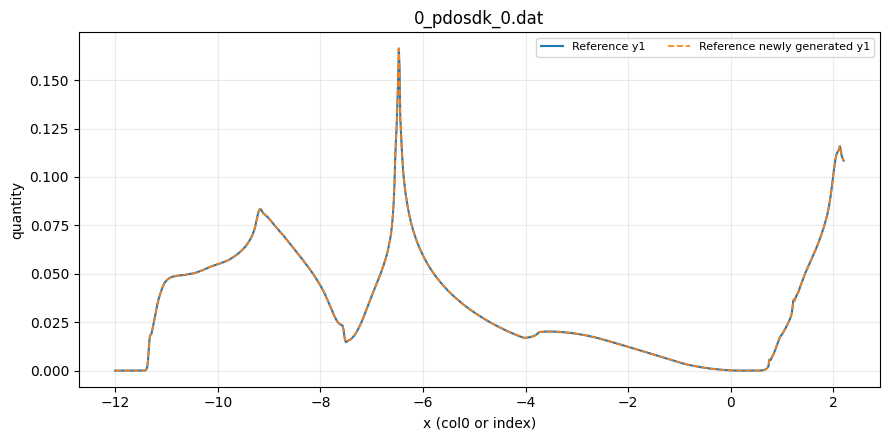

plotted: 10_pdosdk_0.dat | table mode, plotted 1 y-column(s)


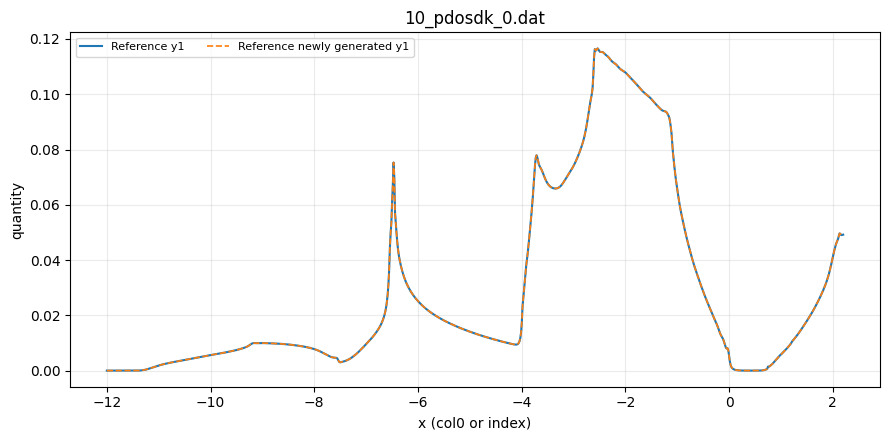

plotted: 11_pdosdk_0.dat | table mode, plotted 1 y-column(s)


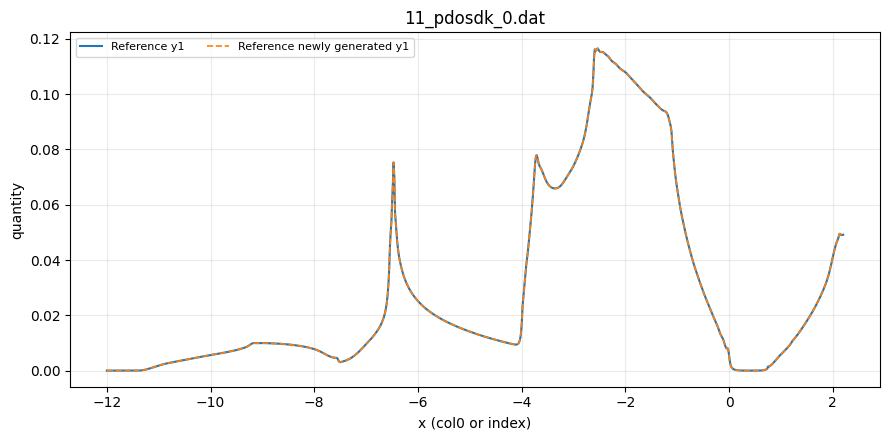

plotted: 12_pdosdk_0.dat | table mode, plotted 1 y-column(s)


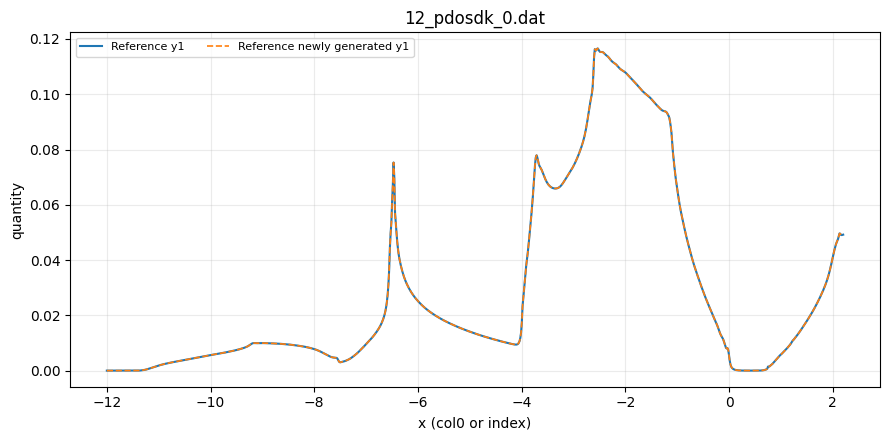

plotted: 13_pdosdk_0.dat | table mode, plotted 1 y-column(s)


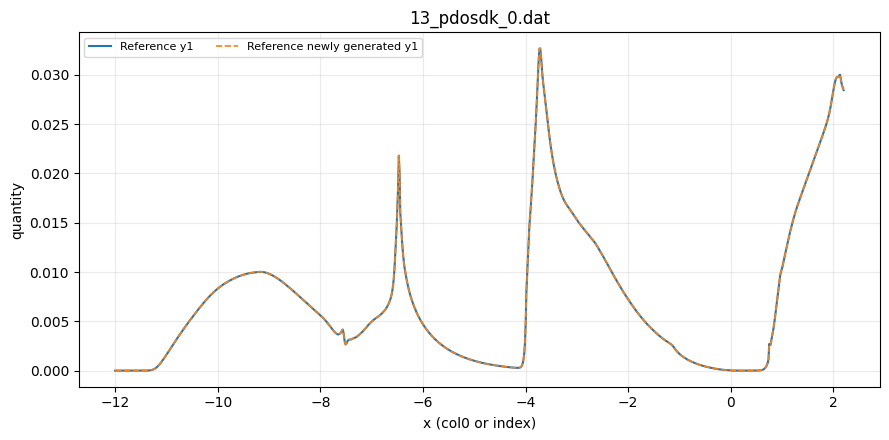

plotted: 14_pdosdk_0.dat | table mode, plotted 1 y-column(s)


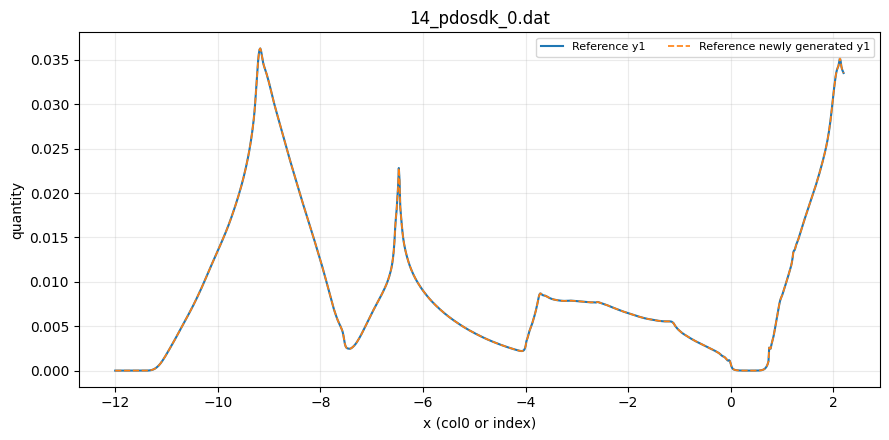

plotted: 15_pdosdk_0.dat | table mode, plotted 1 y-column(s)


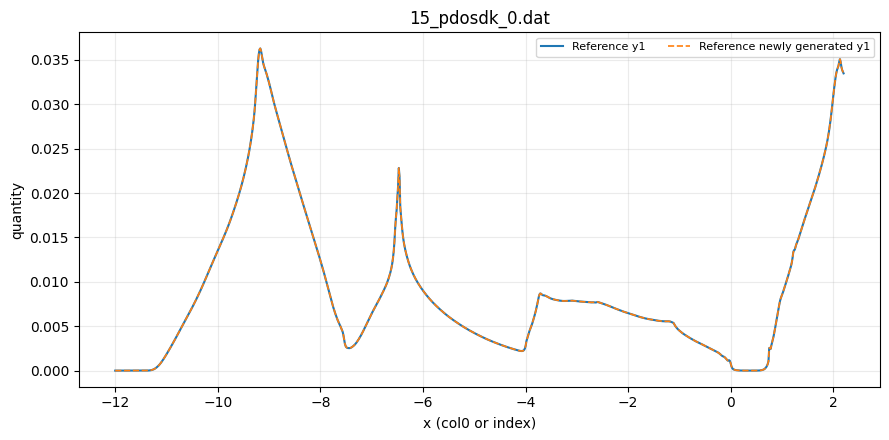

plotted: 16_pdosdk_0.dat | table mode, plotted 1 y-column(s)


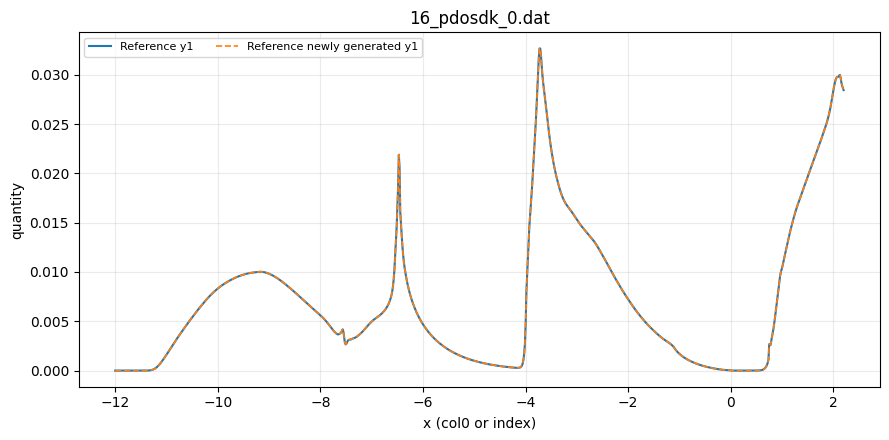

plotted: 17_pdosdk_0.dat | table mode, plotted 1 y-column(s)


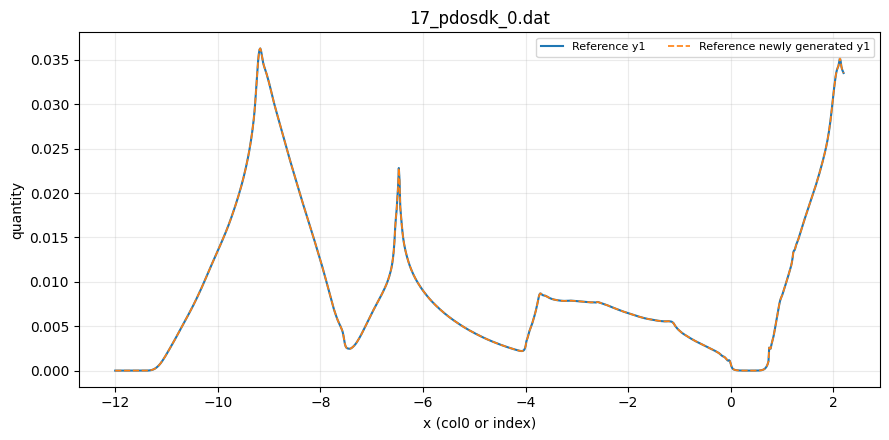

plotted: 1_pdosdk_0.dat | table mode, plotted 1 y-column(s)


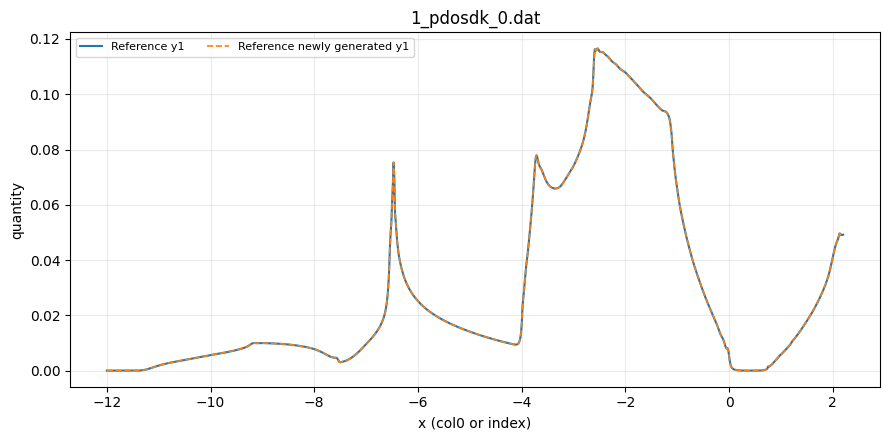

plotted: 2_pdosdk_0.dat | table mode, plotted 1 y-column(s)


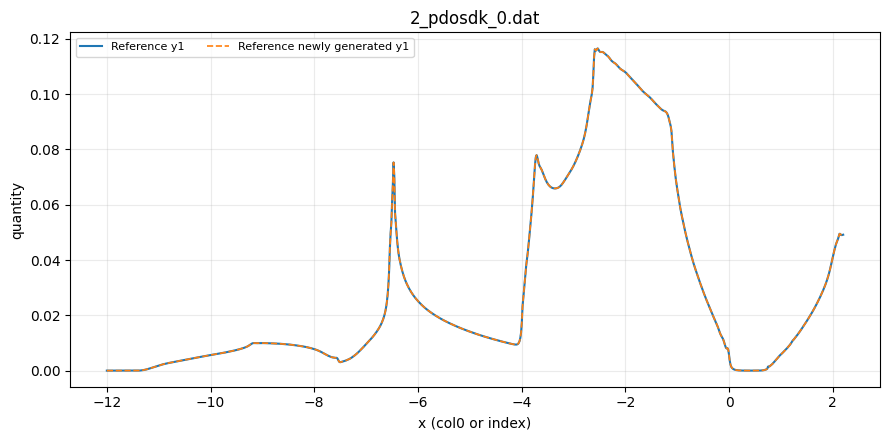

plotted: 3_pdosdk_0.dat | table mode, plotted 1 y-column(s)


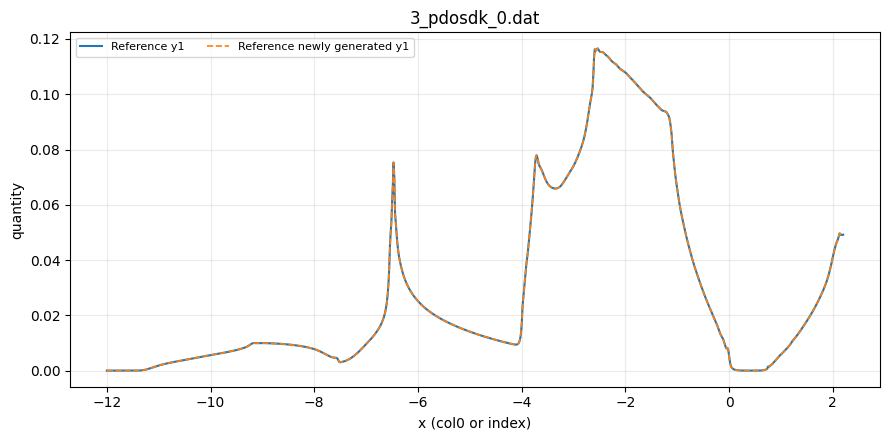

plotted: 4_pdosdk_0.dat | table mode, plotted 1 y-column(s)


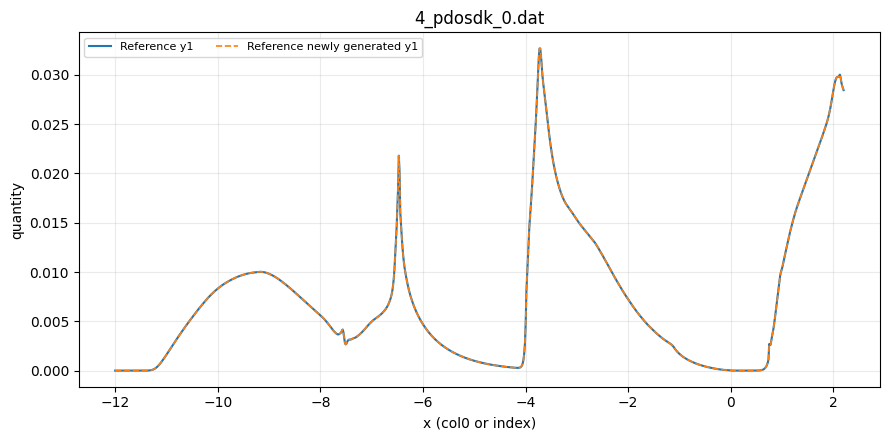

plotted: 5_pdosdk_0.dat | table mode, plotted 1 y-column(s)


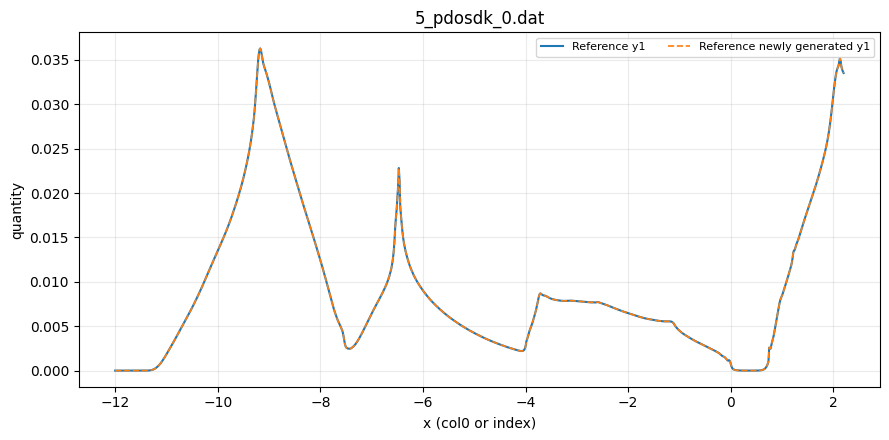

plotted: 6_pdosdk_0.dat | table mode, plotted 1 y-column(s)


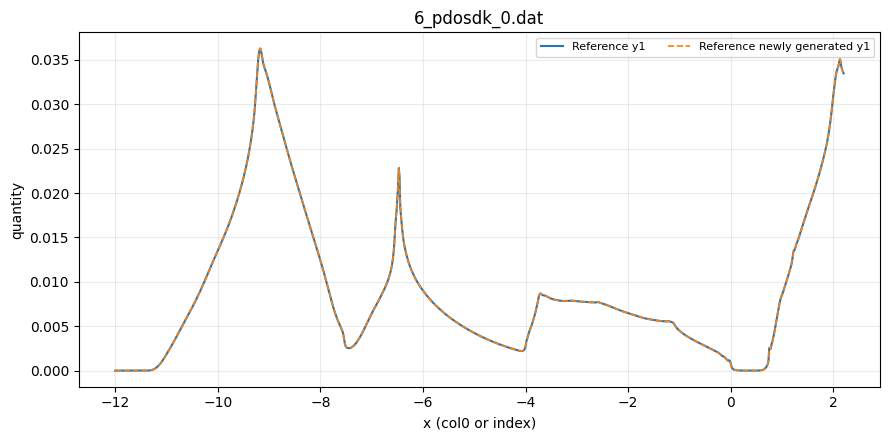

plotted: 7_pdosdk_0.dat | table mode, plotted 1 y-column(s)


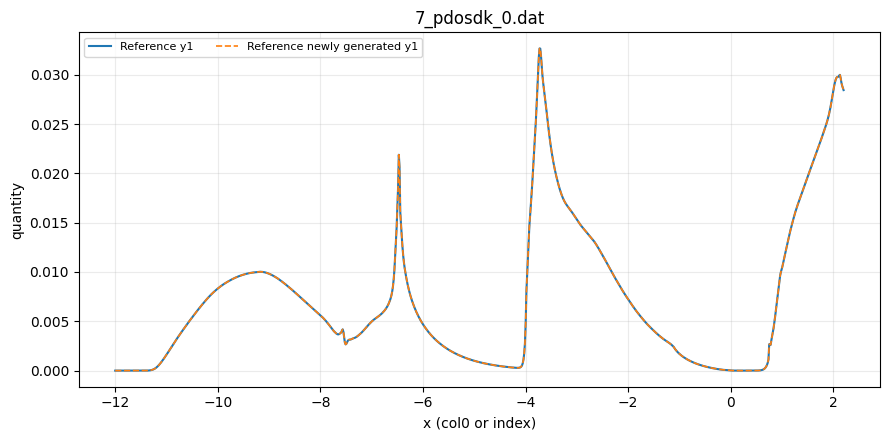

plotted: 8_pdosdk_0.dat | table mode, plotted 1 y-column(s)


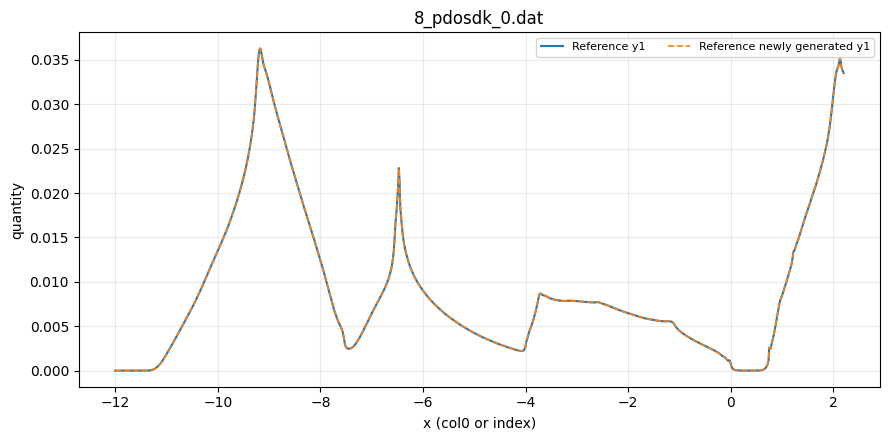

plotted: 9_pdosdk_0.dat | table mode, plotted 1 y-column(s)


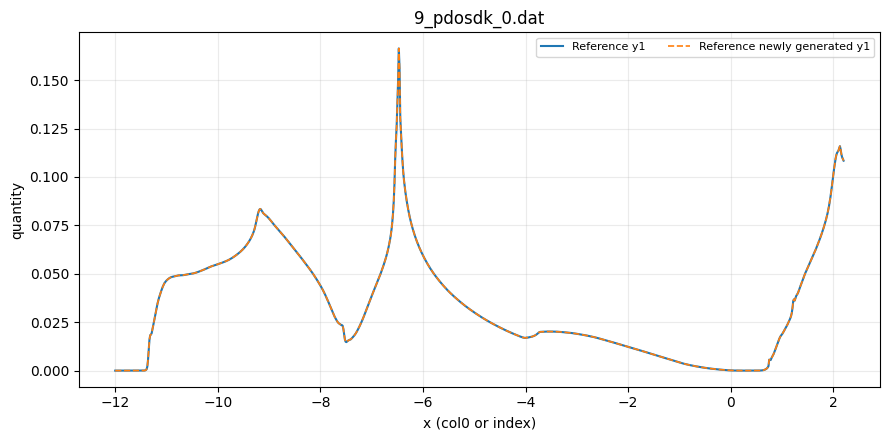

plotted: PFgauss_0.dat | col2-x mode, plotted 6 y-column(s)


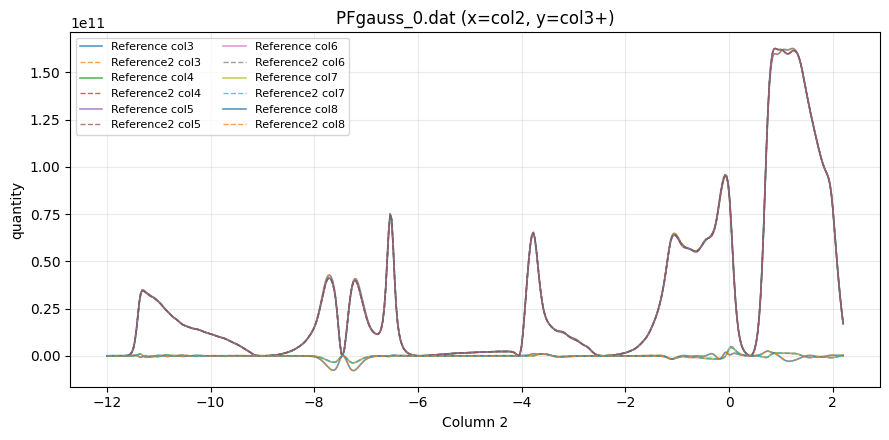

plotted: Seebeckgauss_0.dat | col2-x mode, plotted 6 y-column(s)


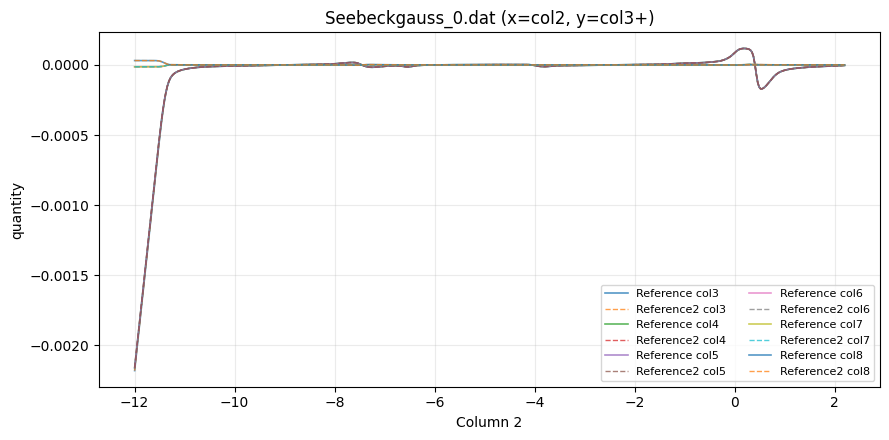

plotted: bands_0.dat | band mode, plotted 18 bands over 2007 points


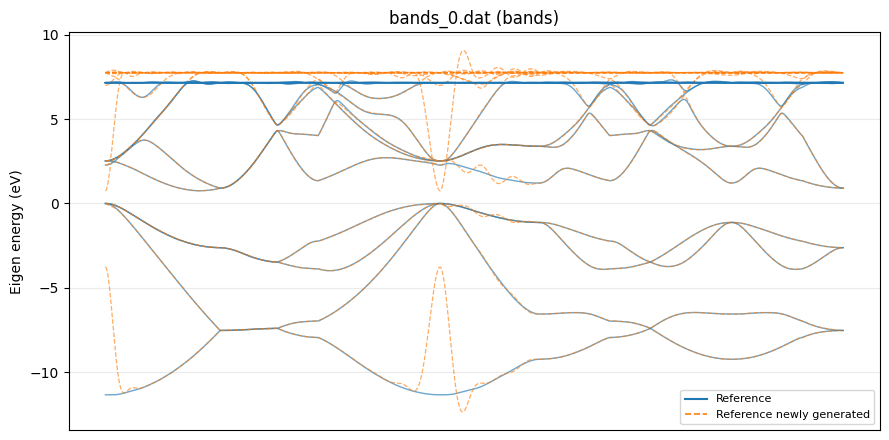

plotted: dosdk_0.dat | table mode, plotted 1 y-column(s)


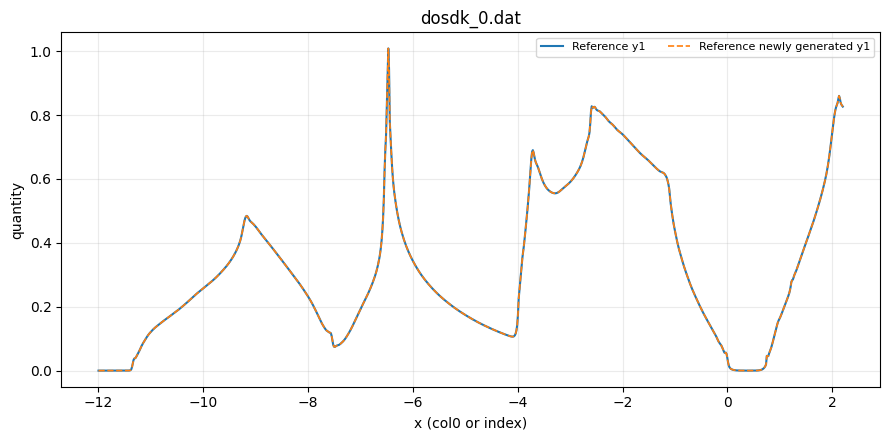

plotted: kappagauss_0.dat | col2-x mode, plotted 6 y-column(s)


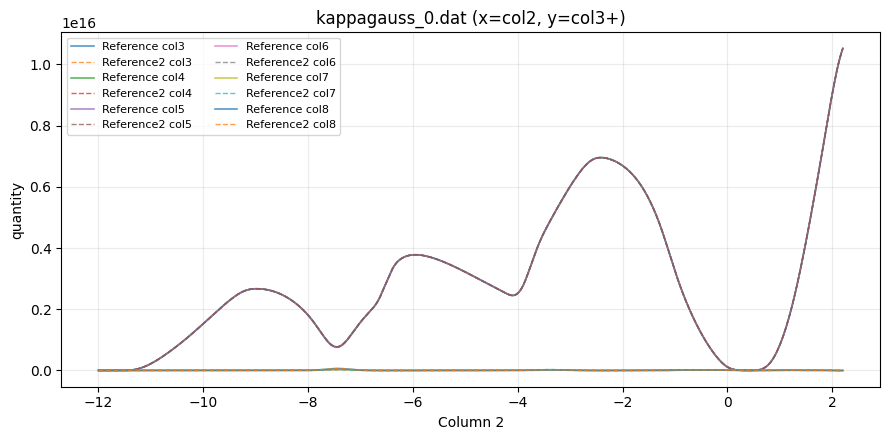

plotted: kpath_points.txt | vector mode, compared 6033 values


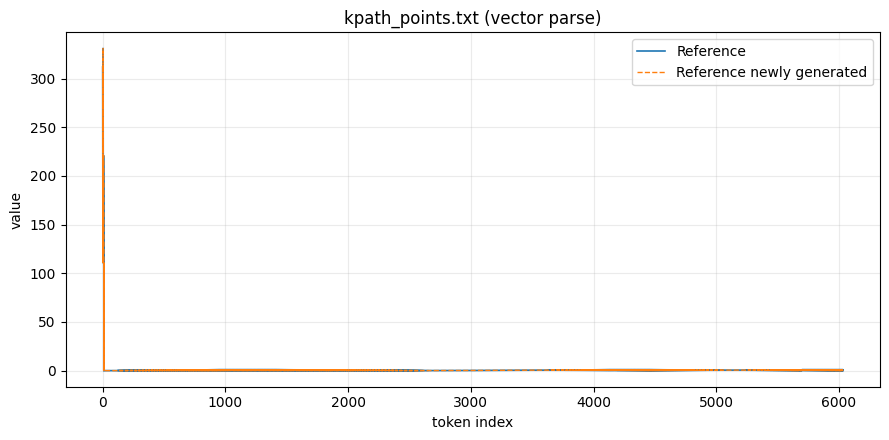

plotted: pdosdk_sum_0.dat | table mode, plotted 1 y-column(s)


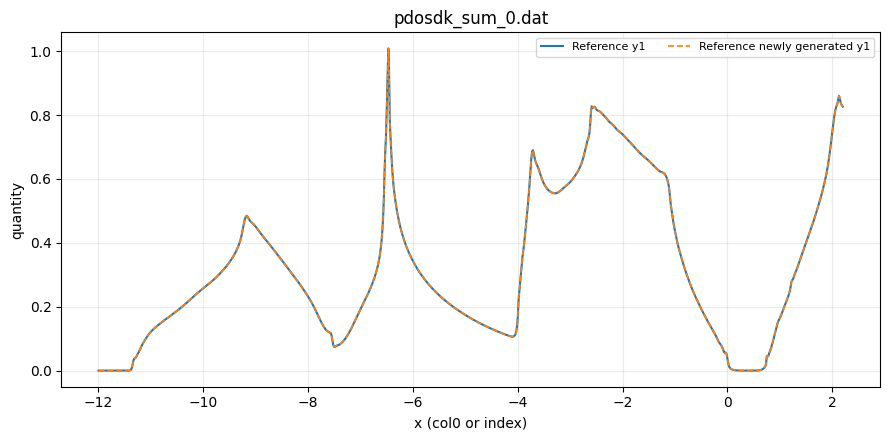

plotted: sigmagauss_0.dat | col2-x mode, plotted 6 y-column(s)


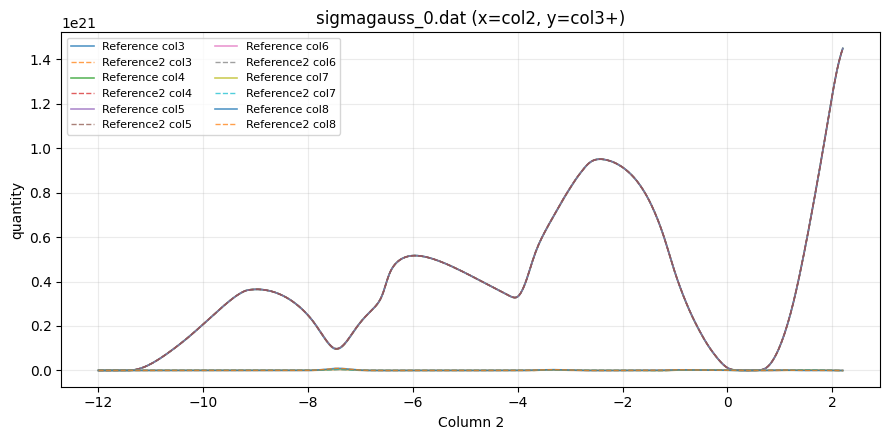

Plotted 26 file(s), skipped 0 file(s).

=== example02 ===
Common files: 1
plotted: dosdk_0.dat | table mode, plotted 1 y-column(s)


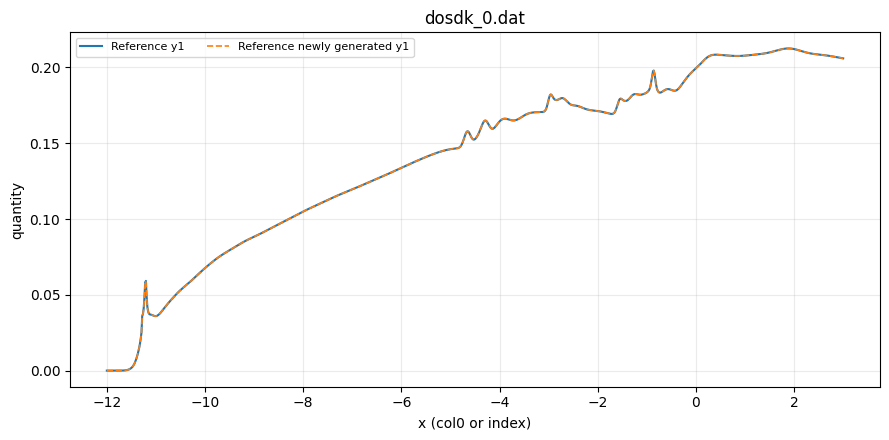

Plotted 1 file(s), skipped 0 file(s).

=== example03 ===
Common files: 24
plotted: 0_pdosdk_0.dat | table mode, plotted 1 y-column(s)


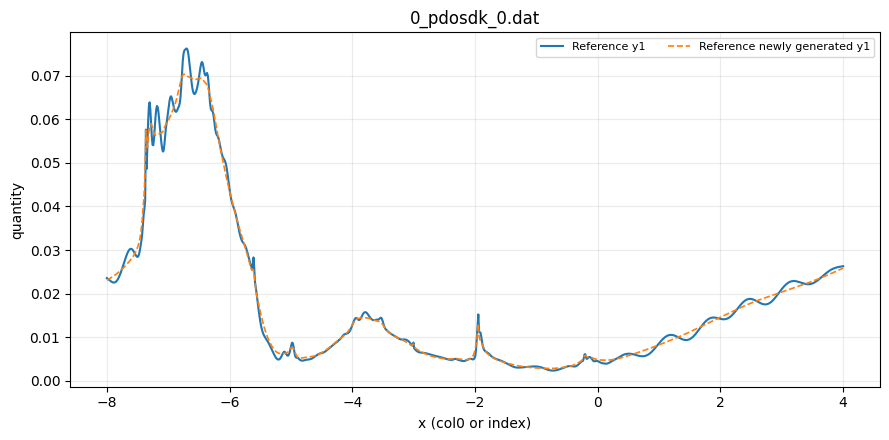

plotted: 0_pdosdk_1.dat | table mode, plotted 1 y-column(s)


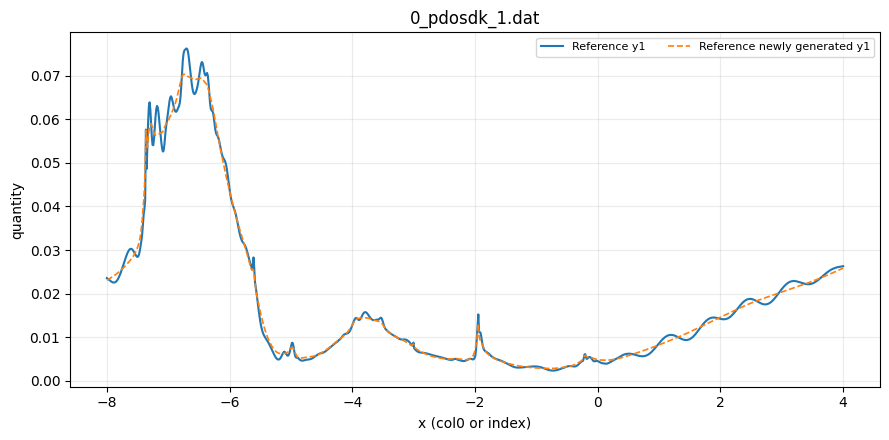

plotted: 1_pdosdk_0.dat | table mode, plotted 1 y-column(s)


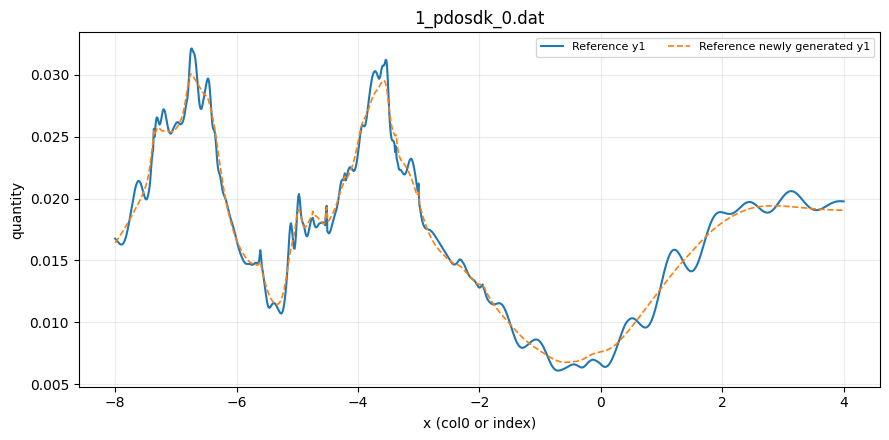

plotted: 1_pdosdk_1.dat | table mode, plotted 1 y-column(s)


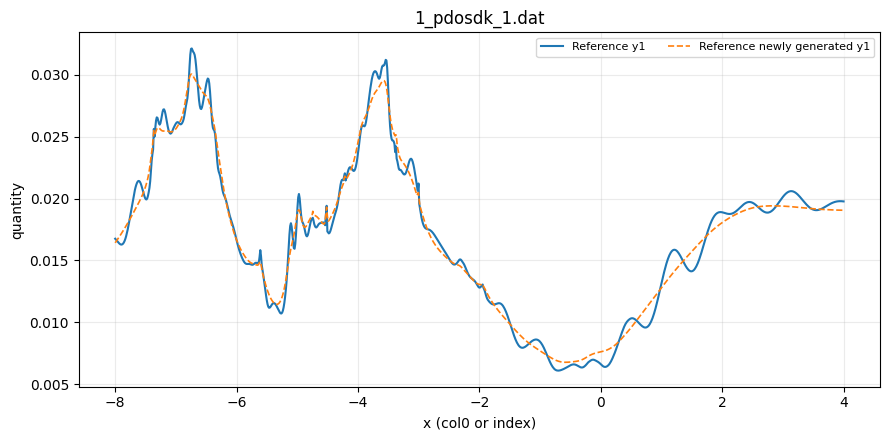

plotted: 2_pdosdk_0.dat | table mode, plotted 1 y-column(s)


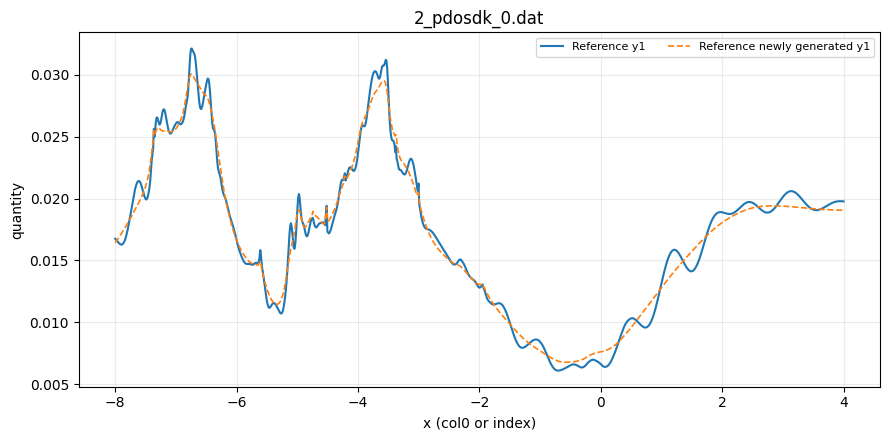

plotted: 2_pdosdk_1.dat | table mode, plotted 1 y-column(s)


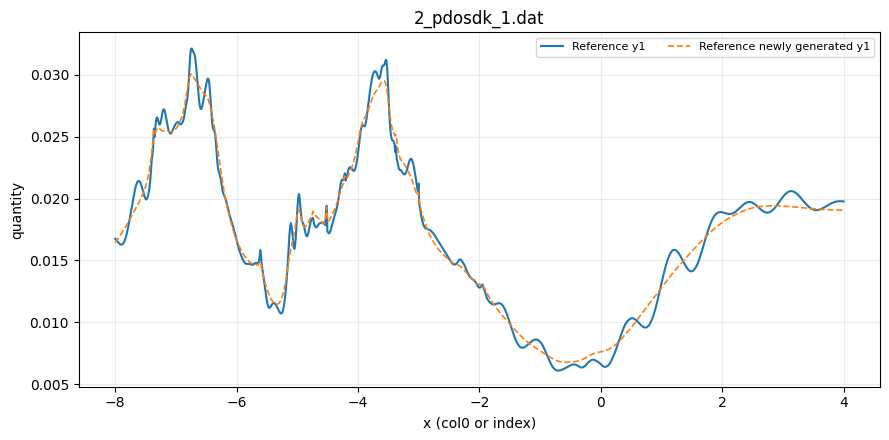

plotted: 3_pdosdk_0.dat | table mode, plotted 1 y-column(s)


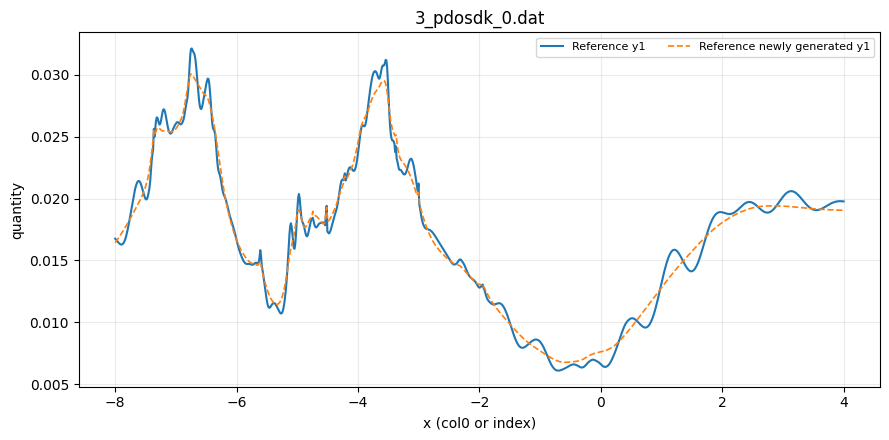

plotted: 3_pdosdk_1.dat | table mode, plotted 1 y-column(s)


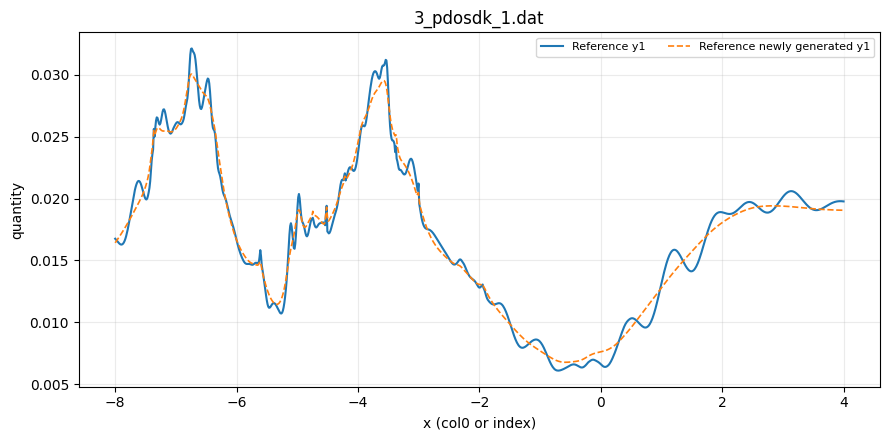

plotted: 4_pdosdk_0.dat | table mode, plotted 1 y-column(s)


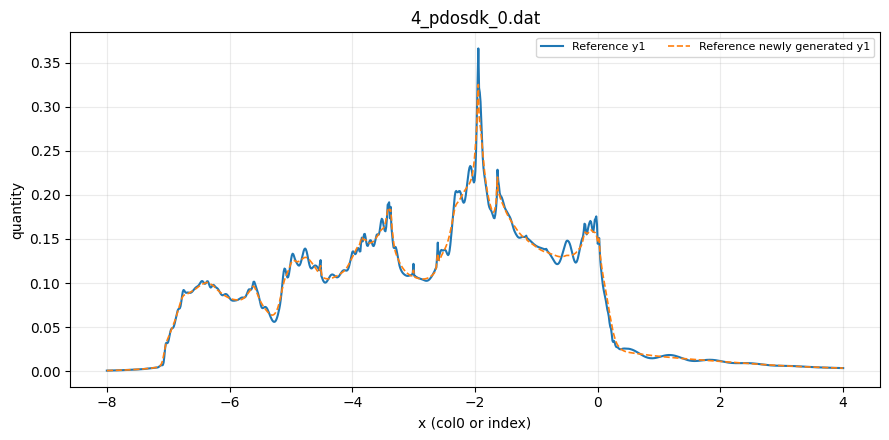

plotted: 4_pdosdk_1.dat | table mode, plotted 1 y-column(s)


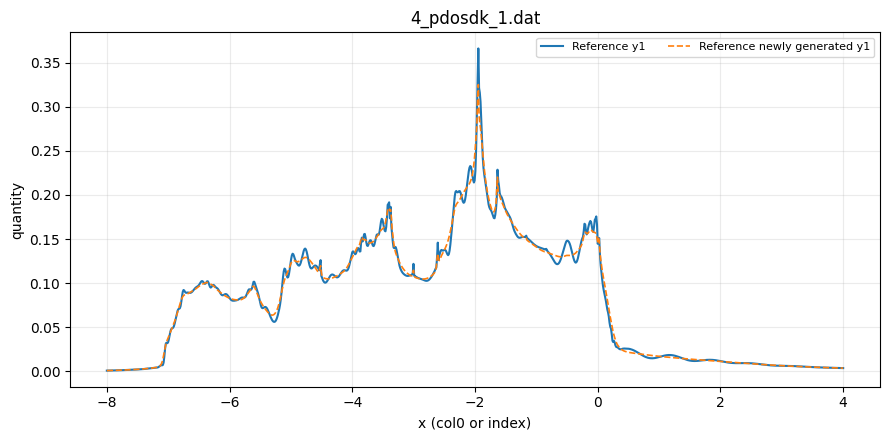

plotted: 5_pdosdk_0.dat | table mode, plotted 1 y-column(s)


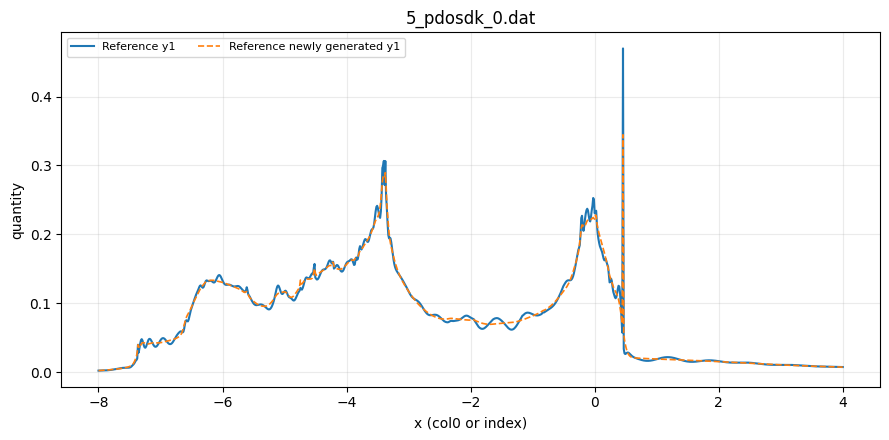

plotted: 5_pdosdk_1.dat | table mode, plotted 1 y-column(s)


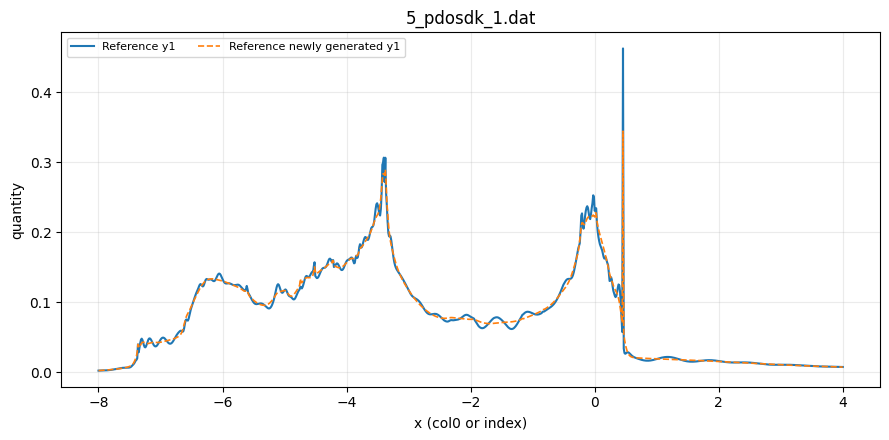

plotted: 6_pdosdk_0.dat | table mode, plotted 1 y-column(s)


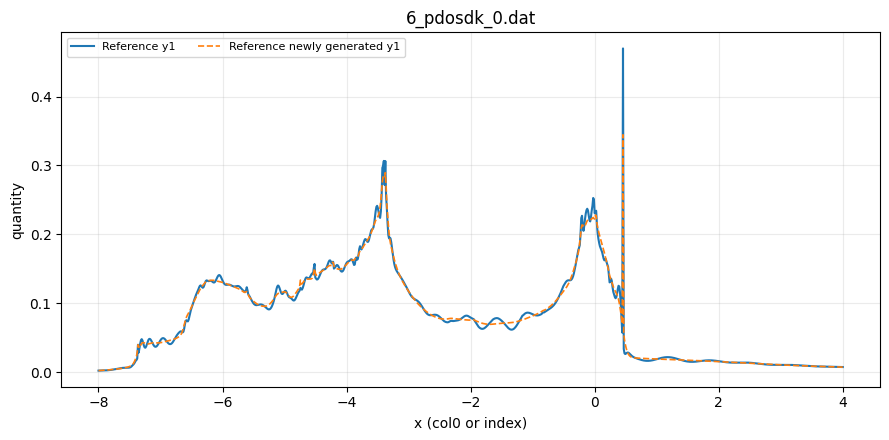

plotted: 6_pdosdk_1.dat | table mode, plotted 1 y-column(s)


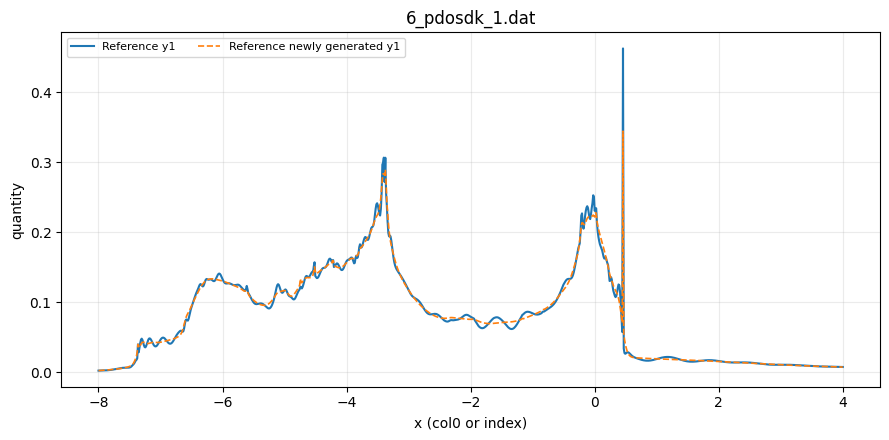

plotted: 7_pdosdk_0.dat | table mode, plotted 1 y-column(s)


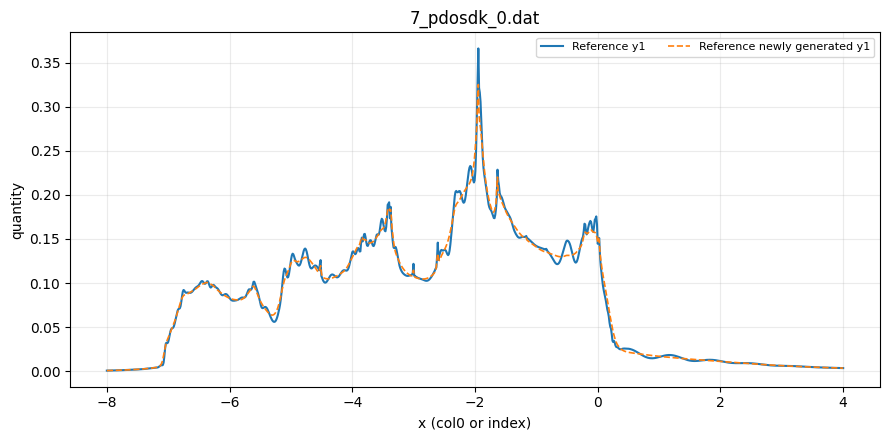

plotted: 7_pdosdk_1.dat | table mode, plotted 1 y-column(s)


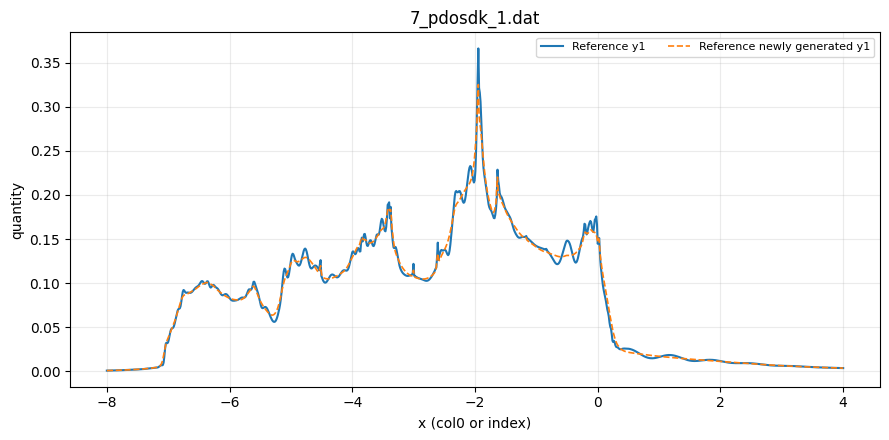

plotted: 8_pdosdk_0.dat | table mode, plotted 1 y-column(s)


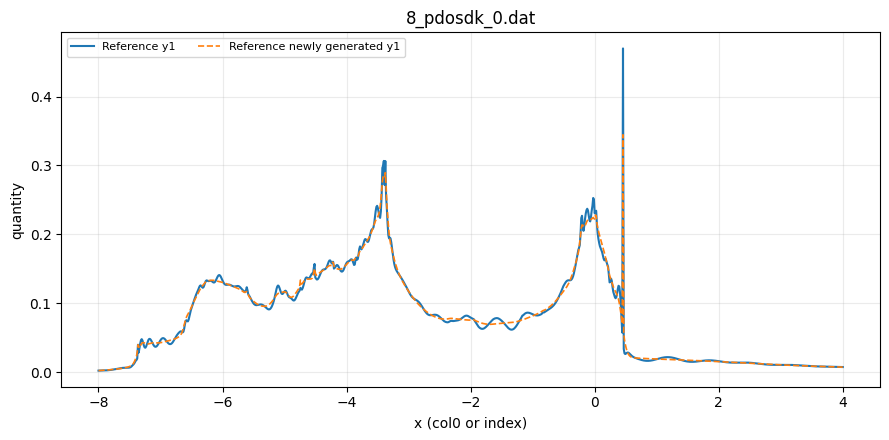

plotted: 8_pdosdk_1.dat | table mode, plotted 1 y-column(s)


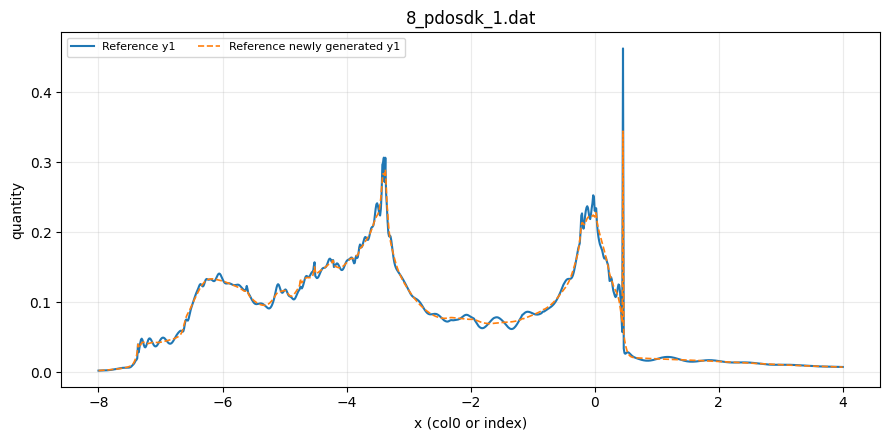

plotted: bands_0.dat | band mode, plotted 9 bands over 506 points


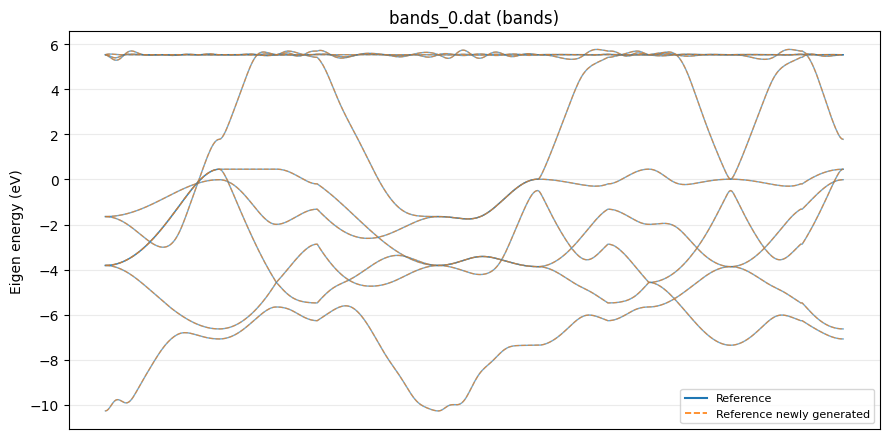

plotted: bands_1.dat | band mode, plotted 9 bands over 506 points


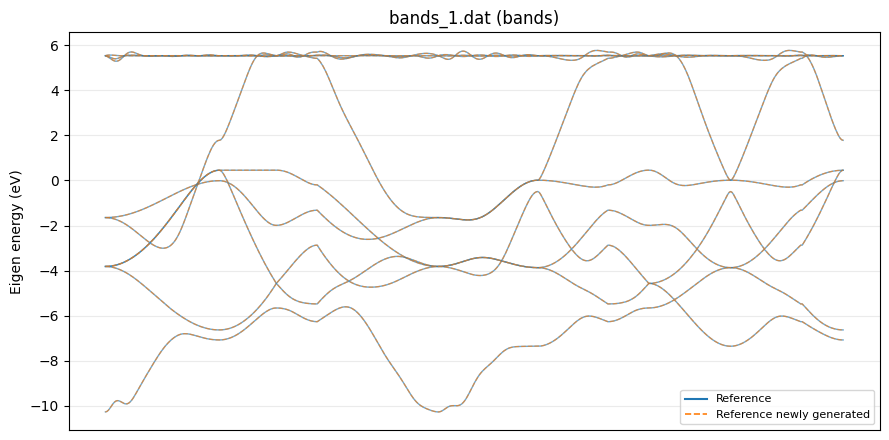

plotted: dosdk_0.dat | table mode, plotted 1 y-column(s)


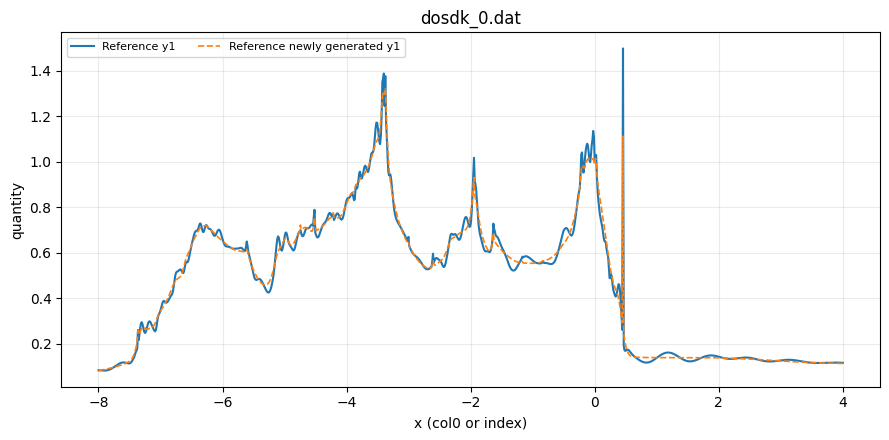

plotted: dosdk_1.dat | table mode, plotted 1 y-column(s)


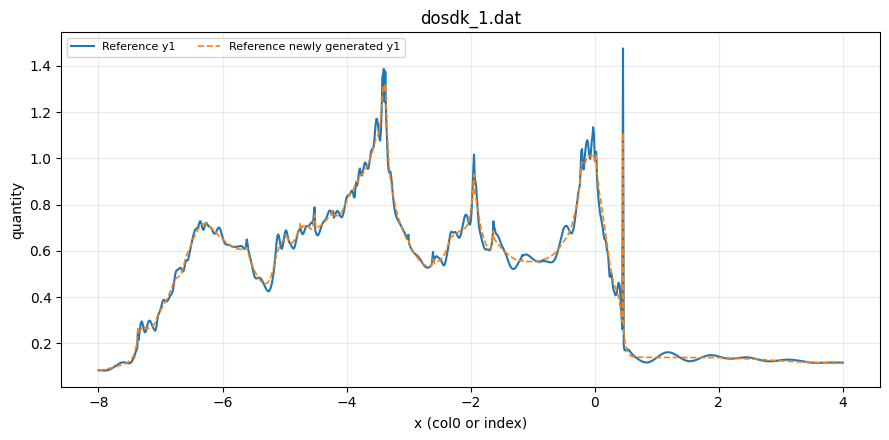

plotted: pdosdk_sum_0.dat | table mode, plotted 1 y-column(s)


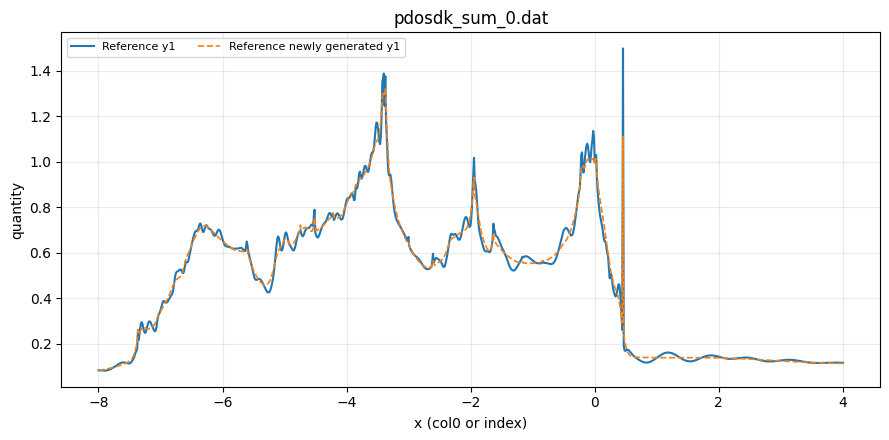

plotted: pdosdk_sum_1.dat | table mode, plotted 1 y-column(s)


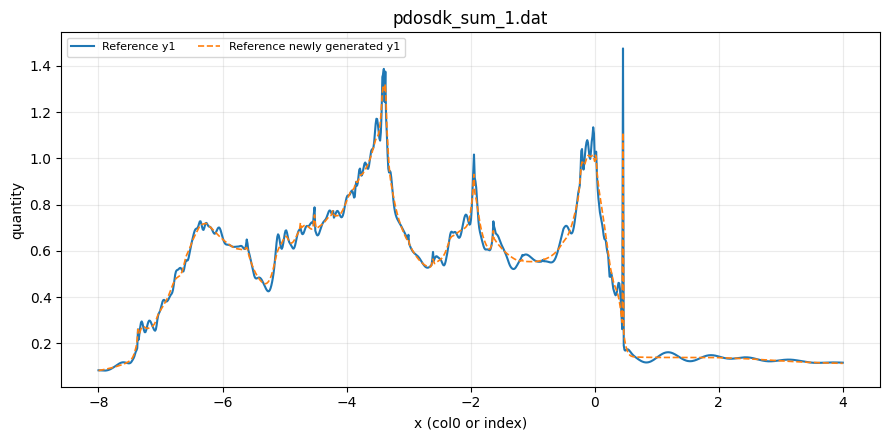

Plotted 24 file(s), skipped 0 file(s).

=== example04 ===
Common files: 11
plotted: Berry_xy.bxsf | vector mode, compared 31275 values


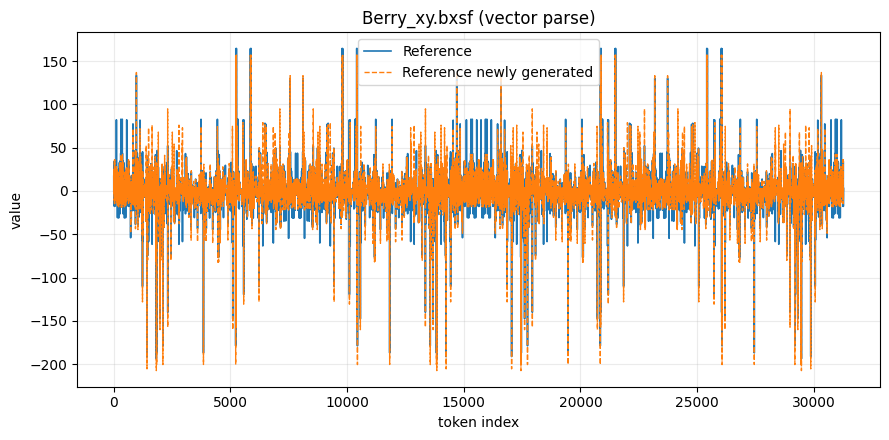

plotted: MCDi_xy.dat | table mode, plotted 1 y-column(s)


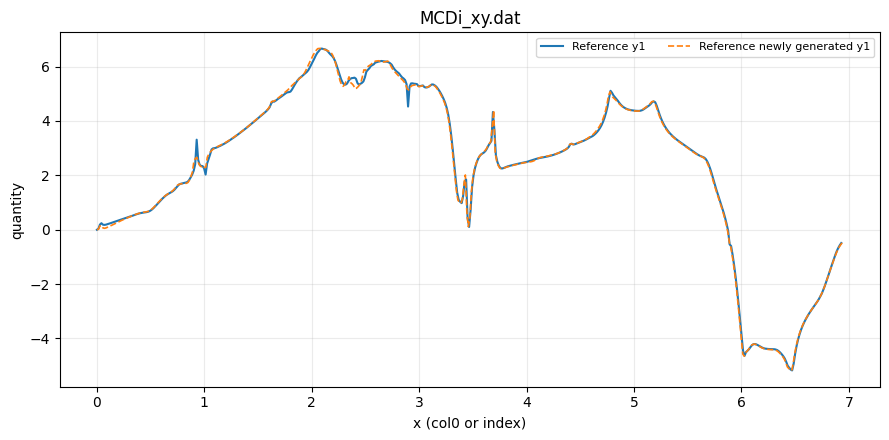

plotted: MCDr_xy.dat | table mode, plotted 1 y-column(s)


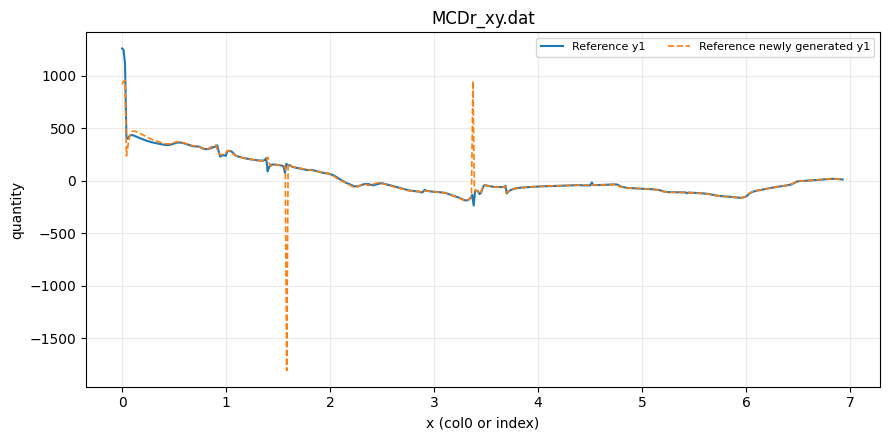

plotted: Omega_z_yz.dat | table mode, plotted 1 y-column(s)


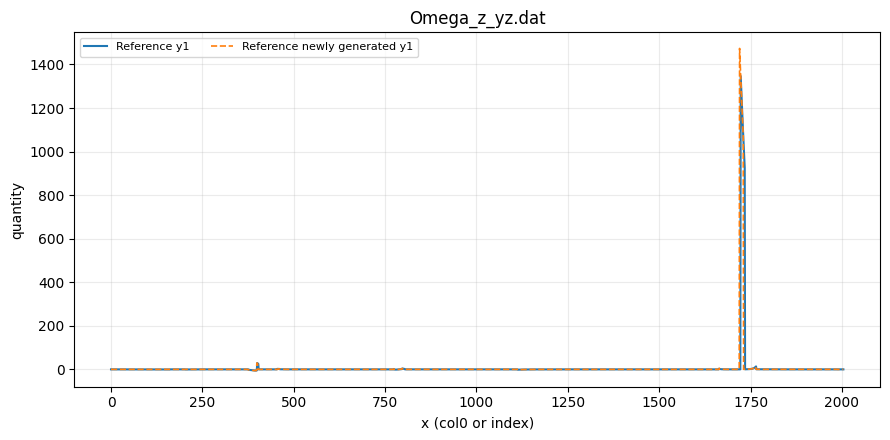

plotted: ahcEf_xy.dat | table mode, plotted 1 y-column(s)


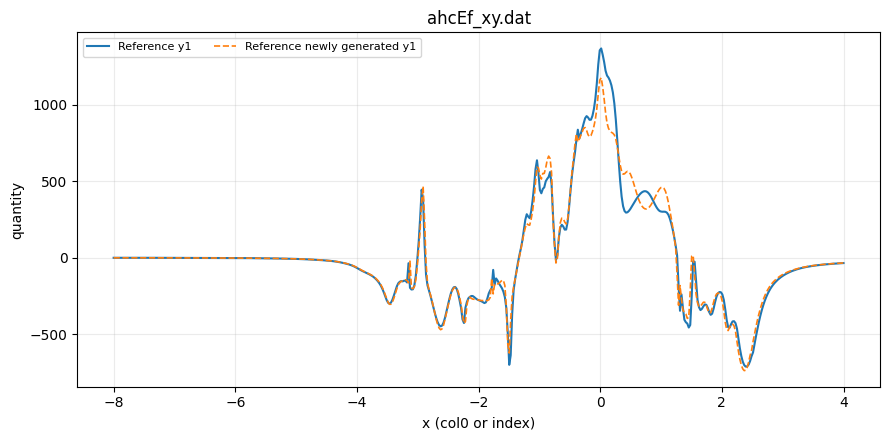

plotted: bands_0.dat | band mode, plotted 26 bands over 2005 points


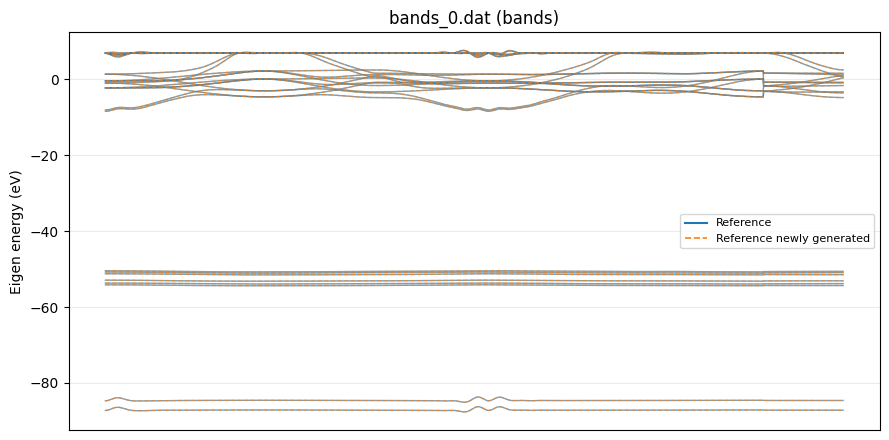

plotted: dosdk_0.dat | table mode, plotted 1 y-column(s)


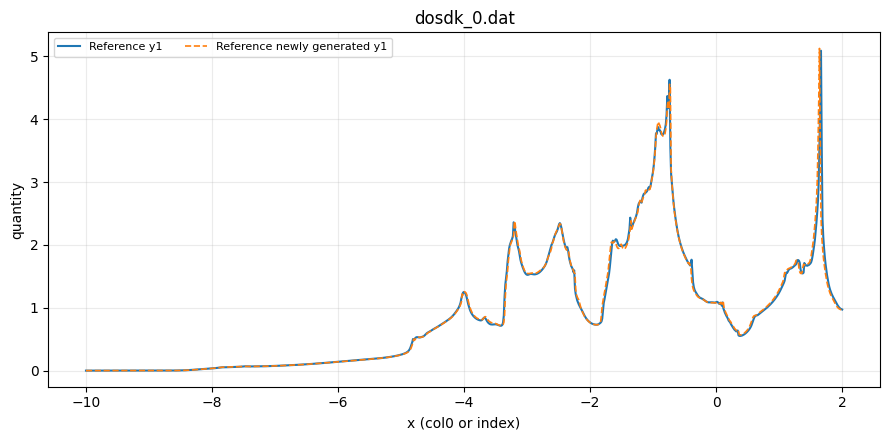

plotted: effmass_yz_0.dat | band mode, plotted 20 bands over 2005 points


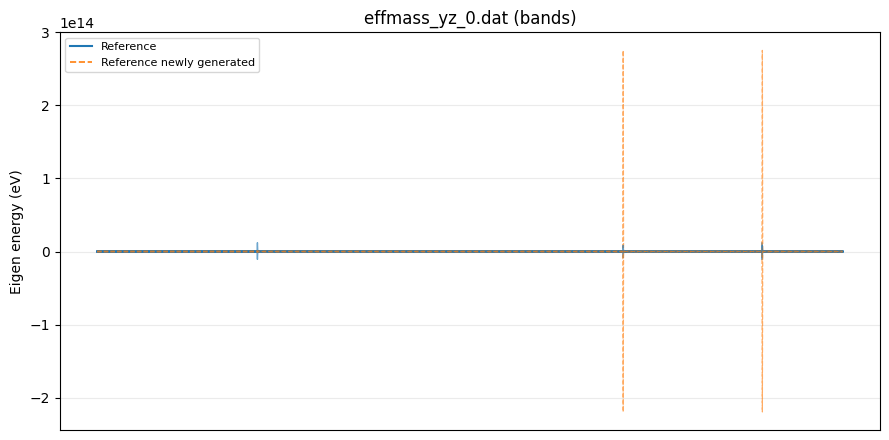

plotted: velocity_0_0.dat | band mode, plotted 20 bands over 2005 points


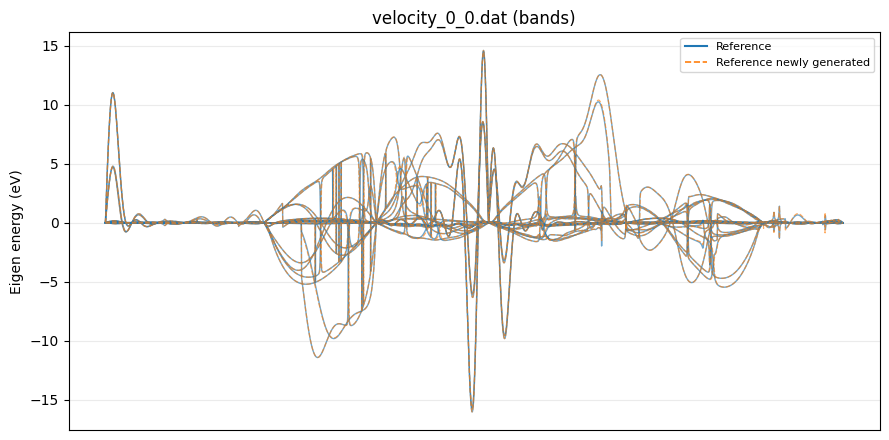

plotted: velocity_1_0.dat | band mode, plotted 20 bands over 2005 points


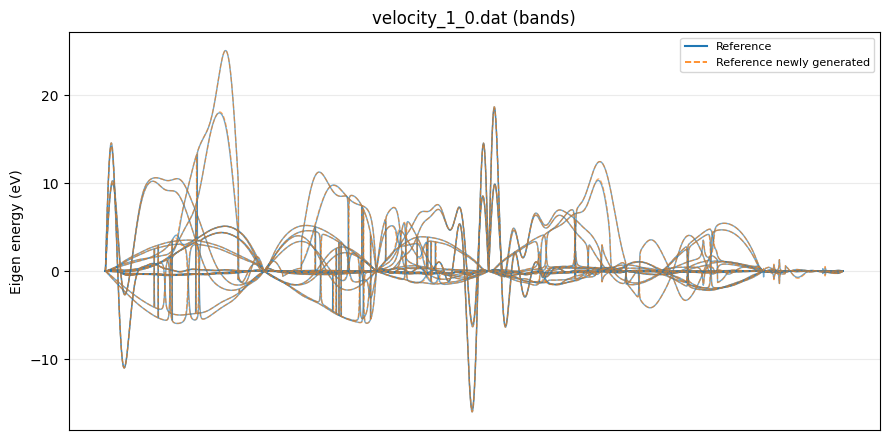

plotted: velocity_2_0.dat | band mode, plotted 20 bands over 2005 points


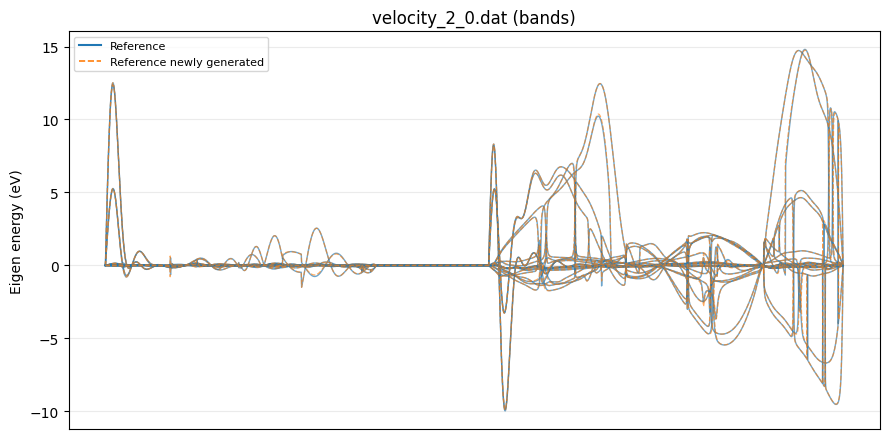

Plotted 11 file(s), skipped 0 file(s).

=== example05 ===
Common files: 9
plotted: Omega_z_xy.dat | table mode, plotted 1 y-column(s)


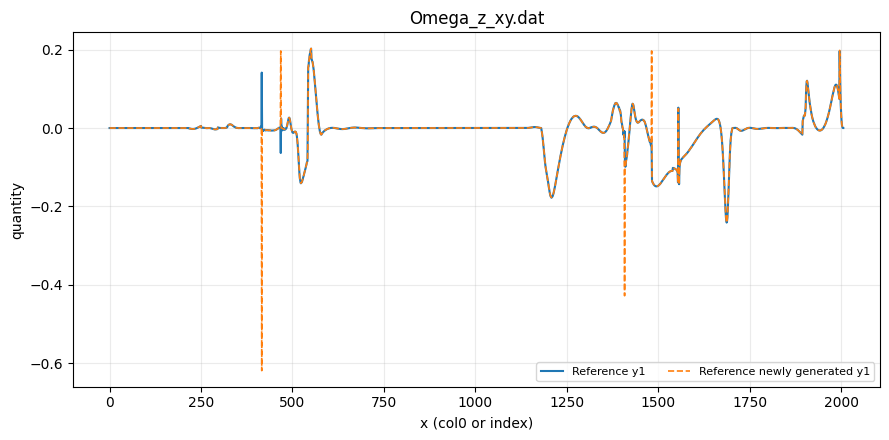

plotted: Omegaj_z_xy.dat | table mode, plotted 1 y-column(s)


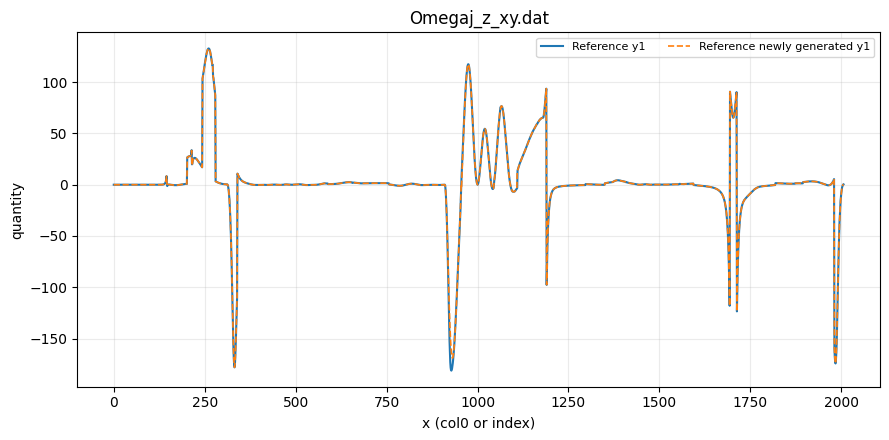

plotted: bands_0.dat | band mode, plotted 18 bands over 2007 points


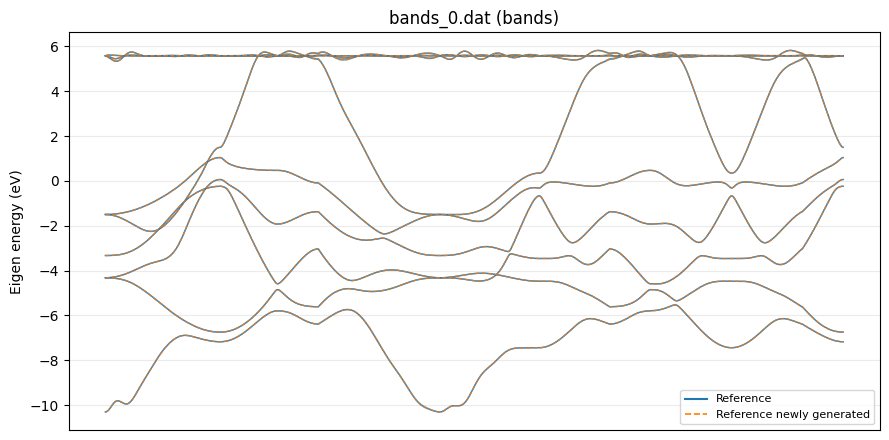

plotted: dosdk_0.dat | table mode, plotted 1 y-column(s)


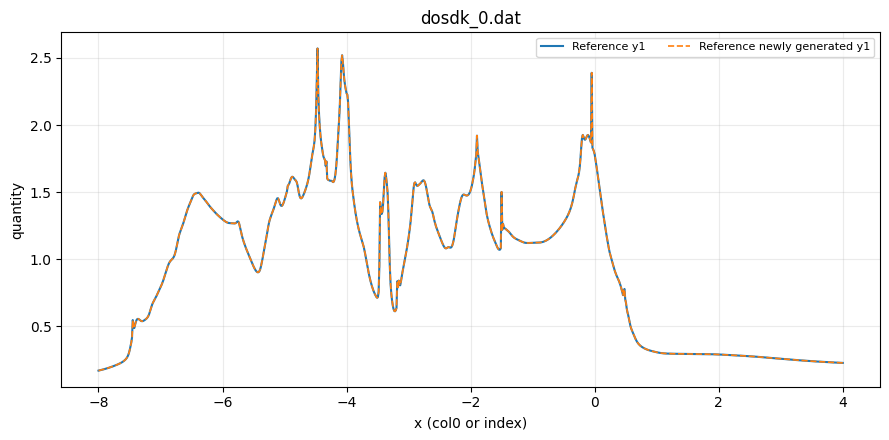

plotted: effmass_xy_0.dat | band mode, plotted 12 bands over 2007 points


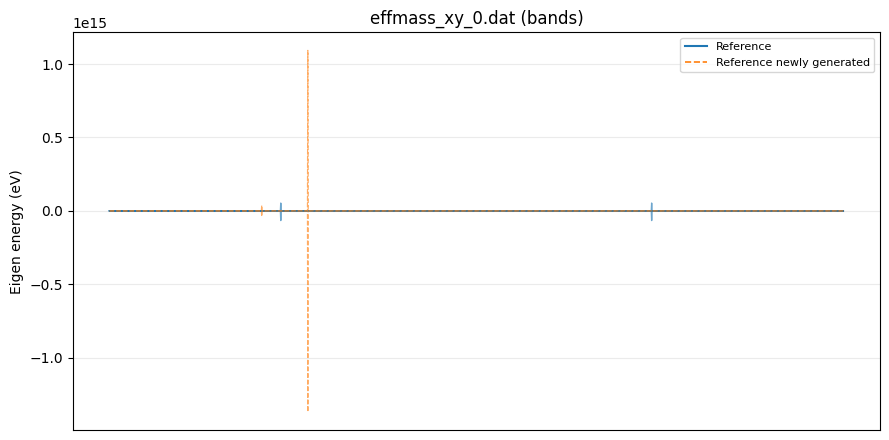

plotted: shcEf_z_xy.dat | table mode, plotted 1 y-column(s)


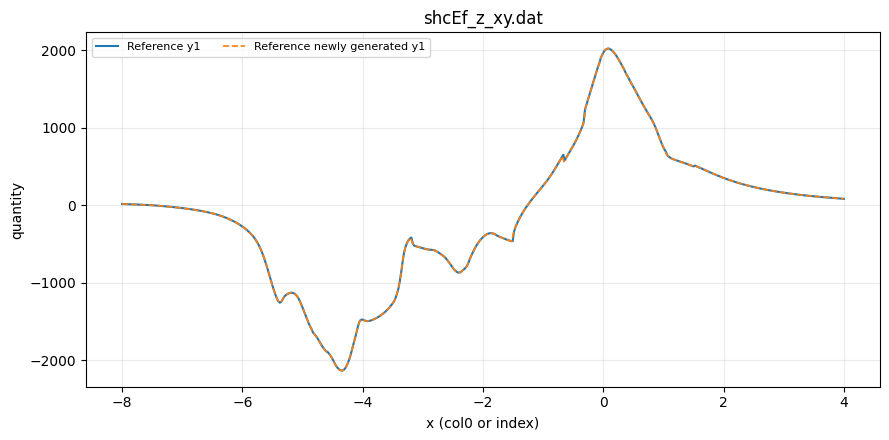

plotted: velocity_0_0.dat | band mode, plotted 12 bands over 2007 points


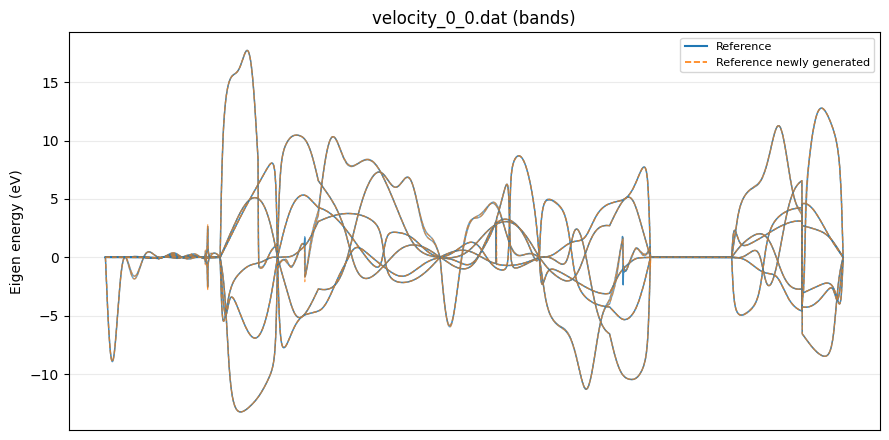

plotted: velocity_1_0.dat | band mode, plotted 12 bands over 2007 points


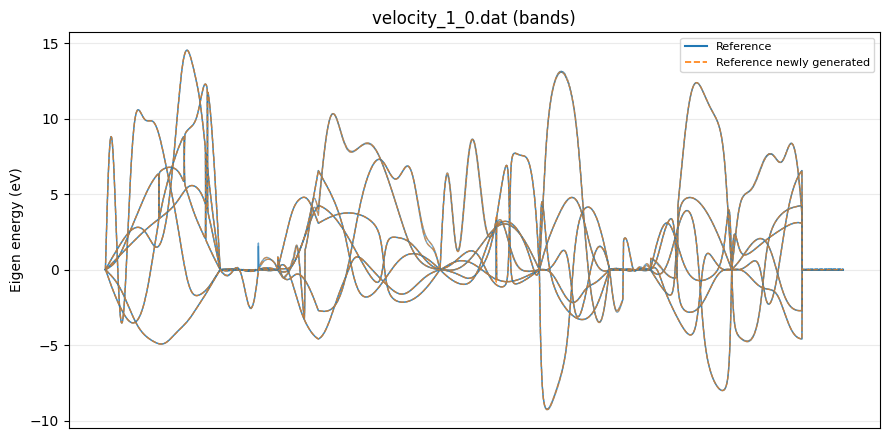

plotted: velocity_2_0.dat | band mode, plotted 12 bands over 2007 points


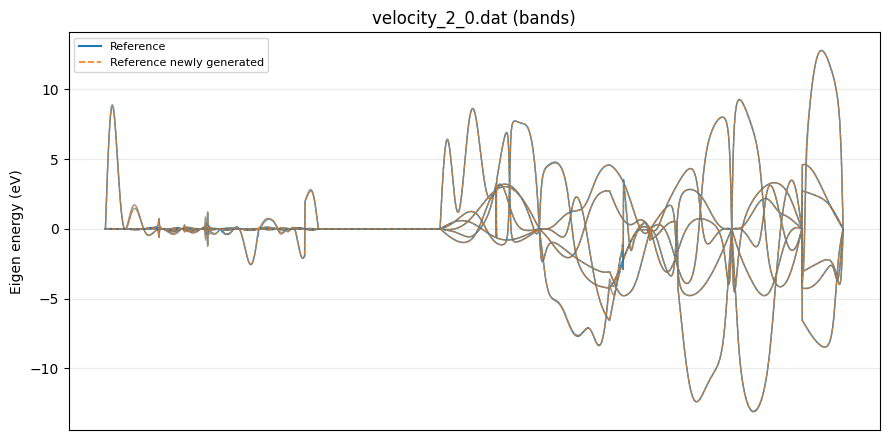

Plotted 9 file(s), skipped 0 file(s).

=== example06 ===
Common files: 2
plotted: bands_0.dat | band mode, plotted 32 bands over 2007 points


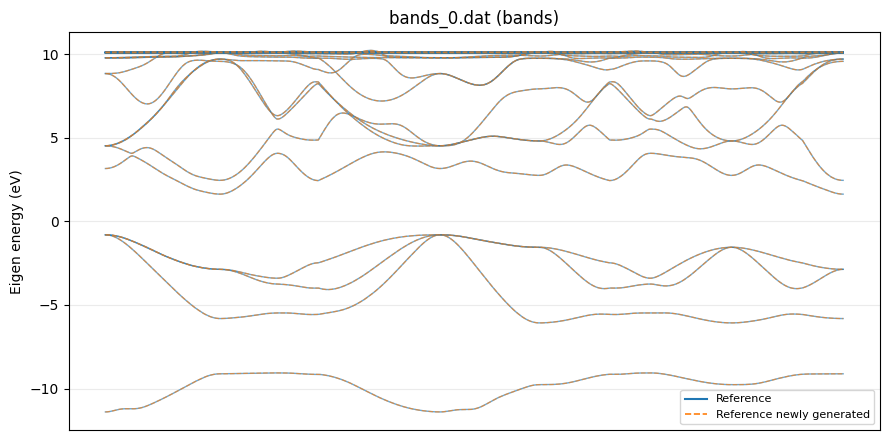

plotted: dosdk_0.dat | table mode, plotted 1 y-column(s)


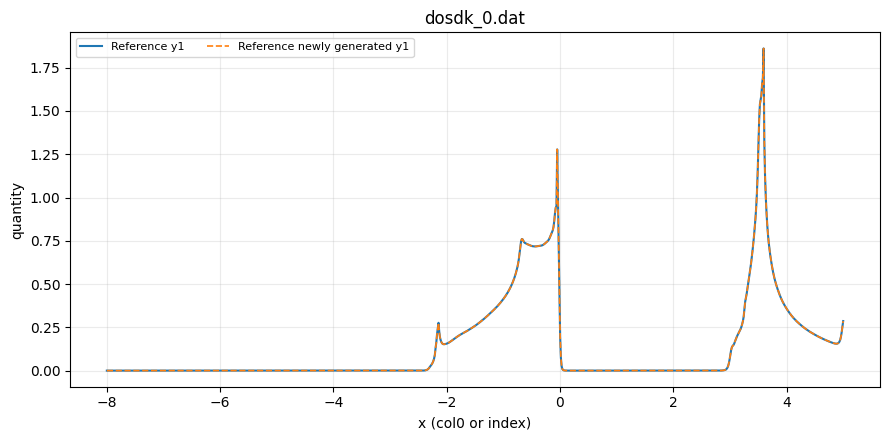

Plotted 2 file(s), skipped 0 file(s).

=== example07 ===
Common files: 9
plotted: Omega_z_xy.dat | table mode, plotted 1 y-column(s)


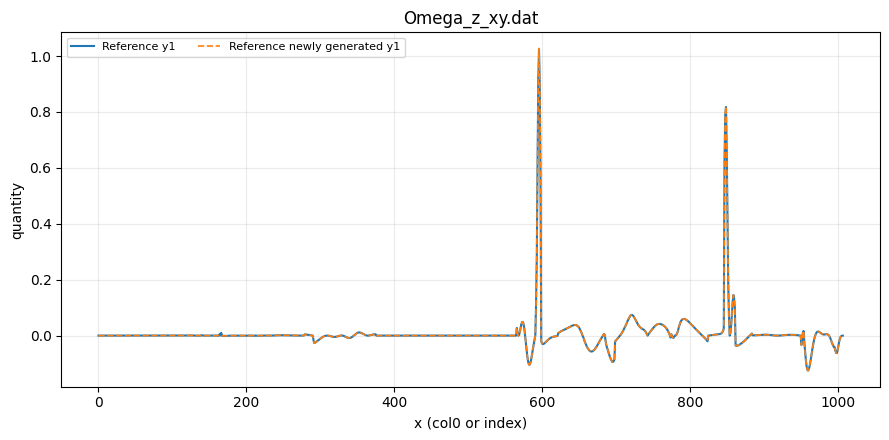

plotted: Omegaj_z_xy.dat | table mode, plotted 1 y-column(s)


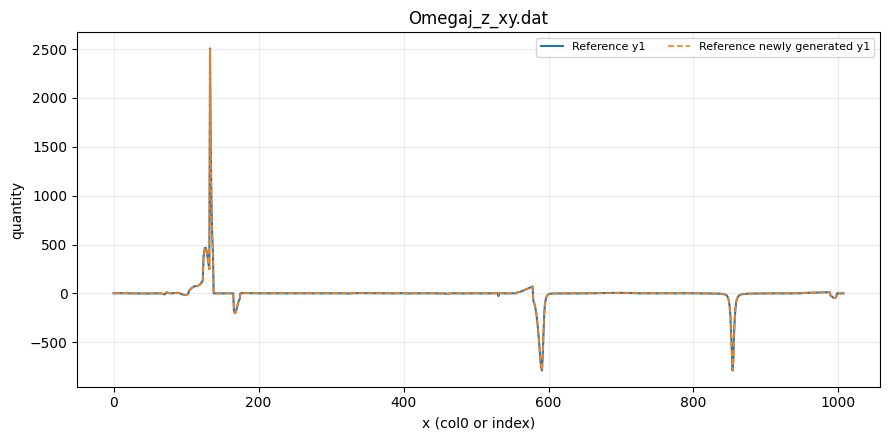

plotted: bands_0.dat | band mode, plotted 18 bands over 1008 points


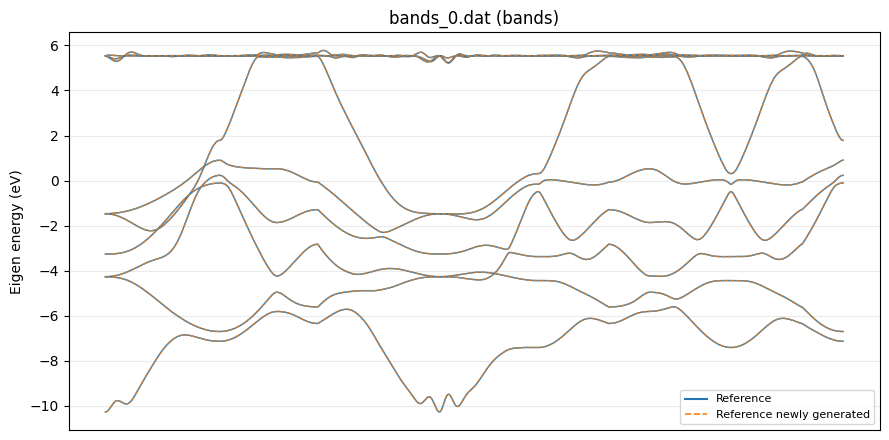

plotted: dosdk_0.dat | table mode, plotted 1 y-column(s)


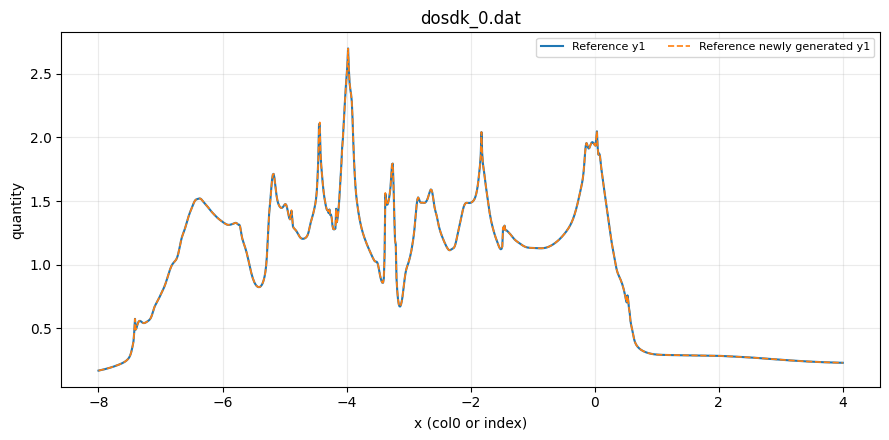

plotted: effmass_xy_0.dat | band mode, plotted 12 bands over 1008 points


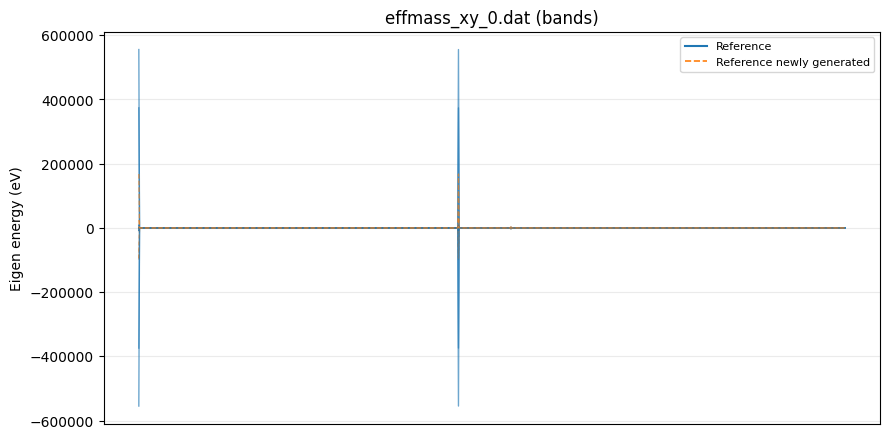

plotted: shcEf_z_xy.dat | table mode, plotted 1 y-column(s)


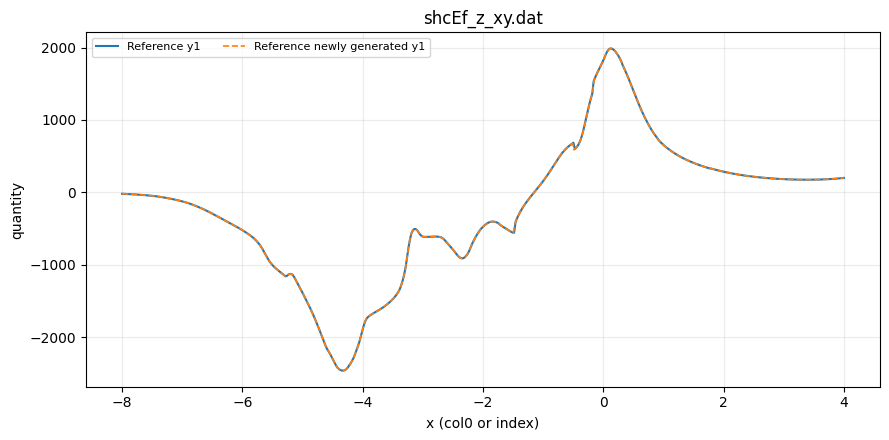

plotted: velocity_0_0.dat | band mode, plotted 12 bands over 1008 points


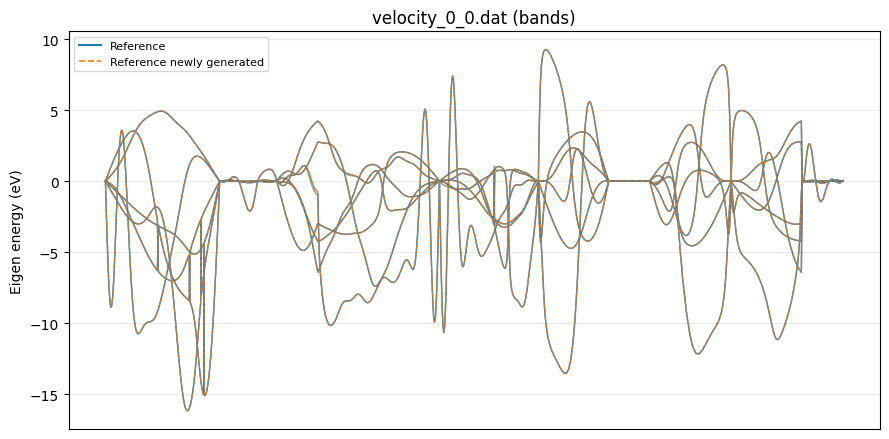

plotted: velocity_1_0.dat | band mode, plotted 12 bands over 1008 points


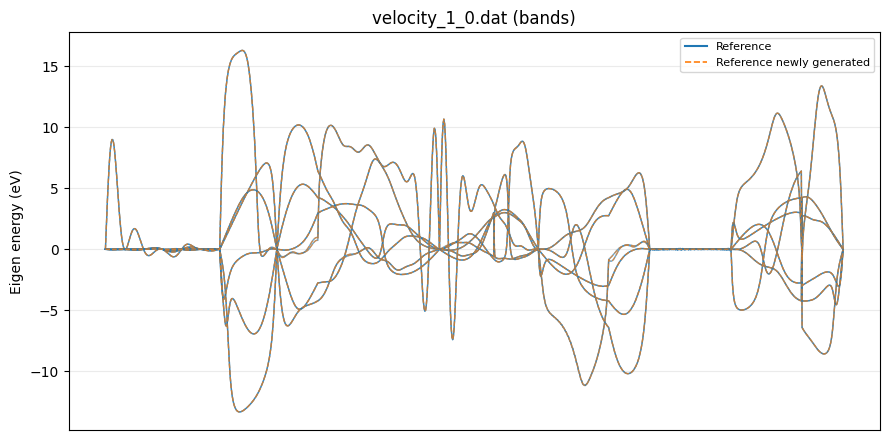

plotted: velocity_2_0.dat | band mode, plotted 12 bands over 1008 points


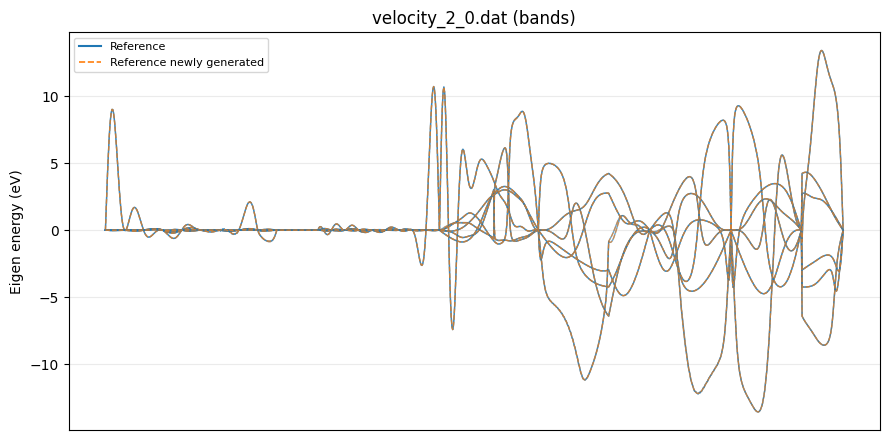

Plotted 9 file(s), skipped 0 file(s).

=== example08 ===
Common files: 3
plotted: bands_0.dat | band mode, plotted 72 bands over 1003 points


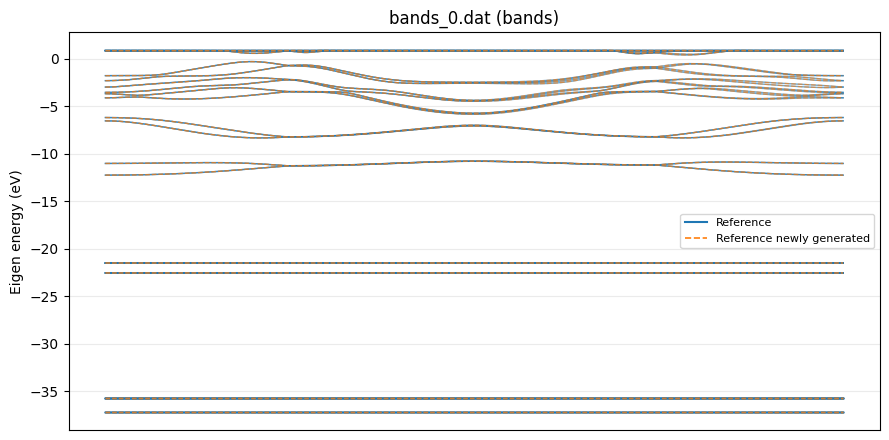

plotted: shcEf_z_xy.dat | table mode, plotted 1 y-column(s)


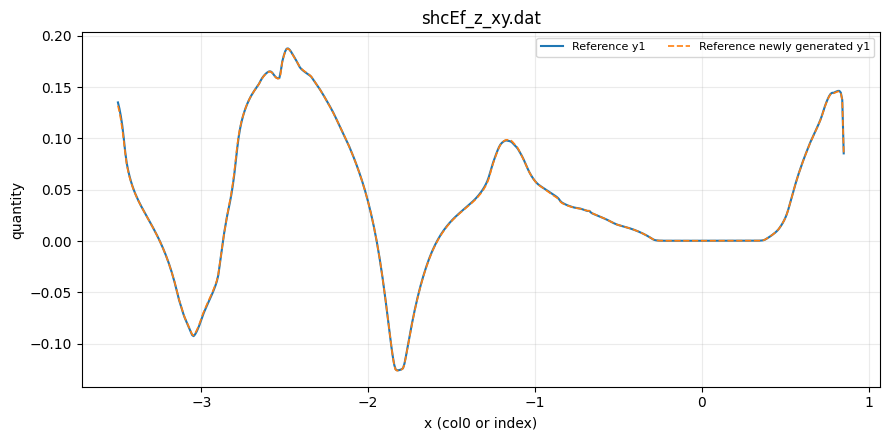

plotted: shcEf_z_yx.dat | table mode, plotted 1 y-column(s)


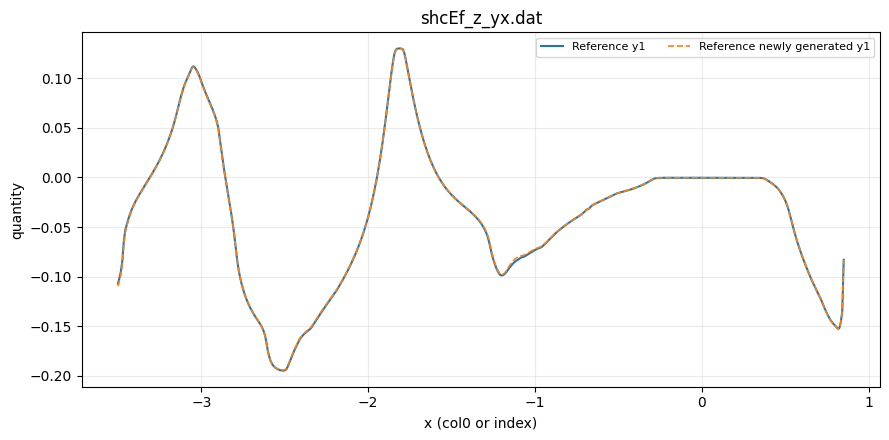

Plotted 3 file(s), skipped 0 file(s).

=== example09 ===
Common files: 1
plotted: weyl_points.dat | vector mode, compared 19 values


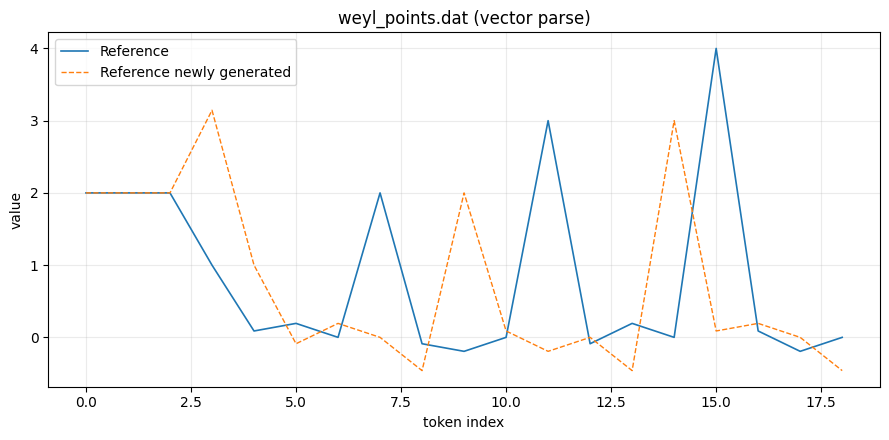

Plotted 1 file(s), skipped 0 file(s).

=== example11 ===
Common files: 13
plotted: Ekai_xx.dat | table mode, plotted 1 y-column(s)


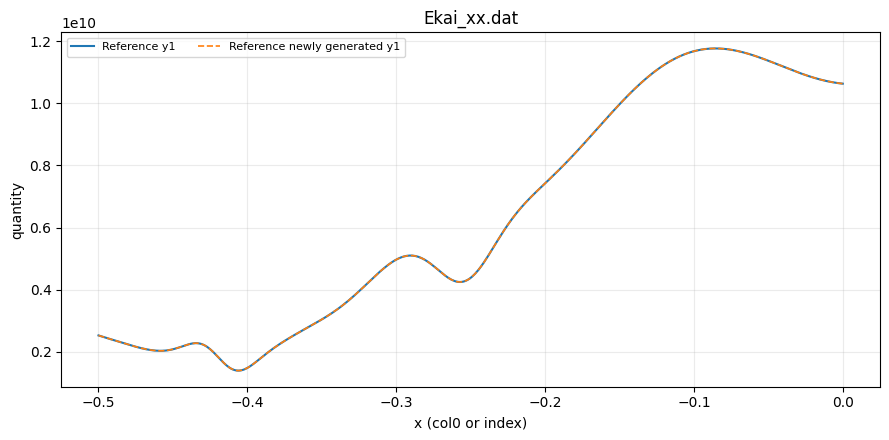

plotted: Ekai_xy.dat | table mode, plotted 1 y-column(s)


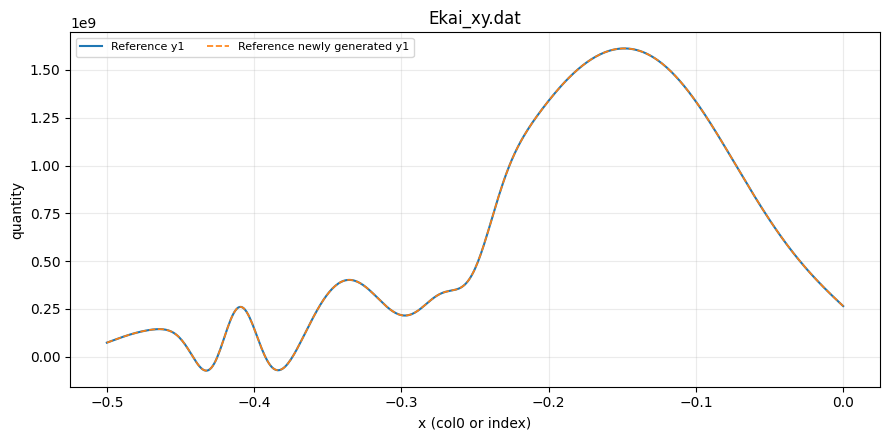

plotted: Ekai_xz.dat | table mode, plotted 1 y-column(s)


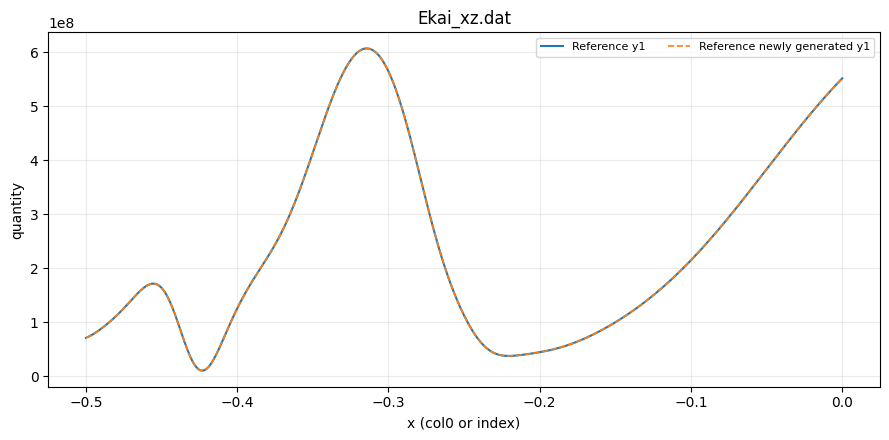

plotted: Ekai_yx.dat | table mode, plotted 1 y-column(s)


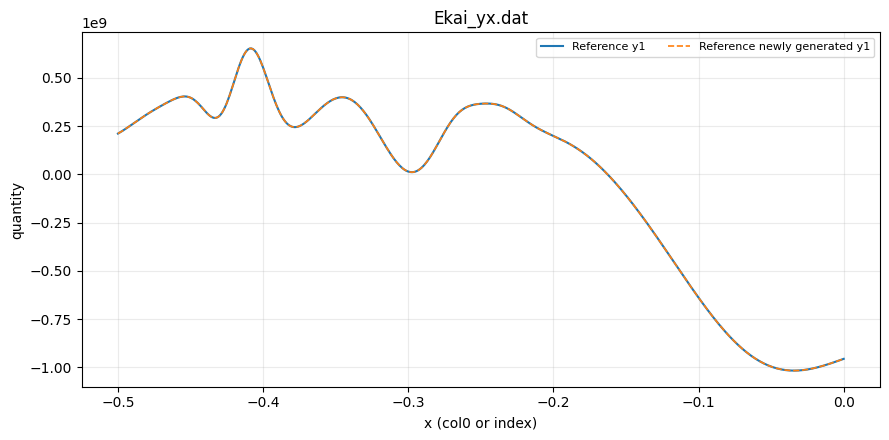

plotted: Ekai_yy.dat | table mode, plotted 1 y-column(s)


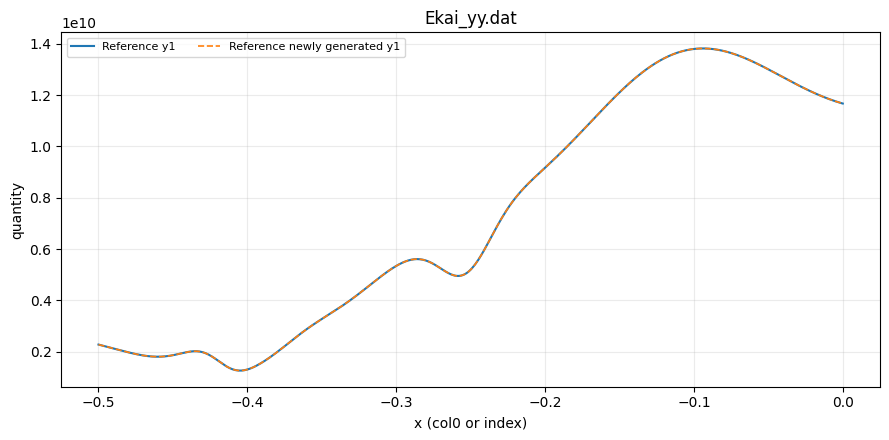

plotted: Ekai_yz.dat | table mode, plotted 1 y-column(s)


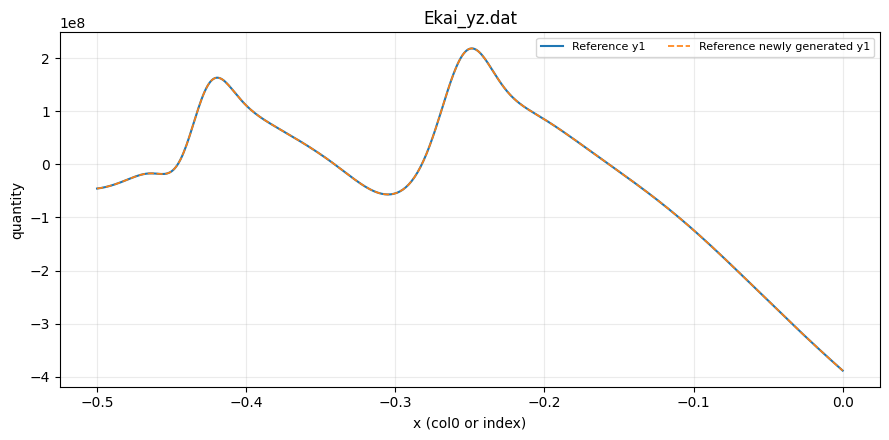

plotted: Ekai_zx.dat | table mode, plotted 1 y-column(s)


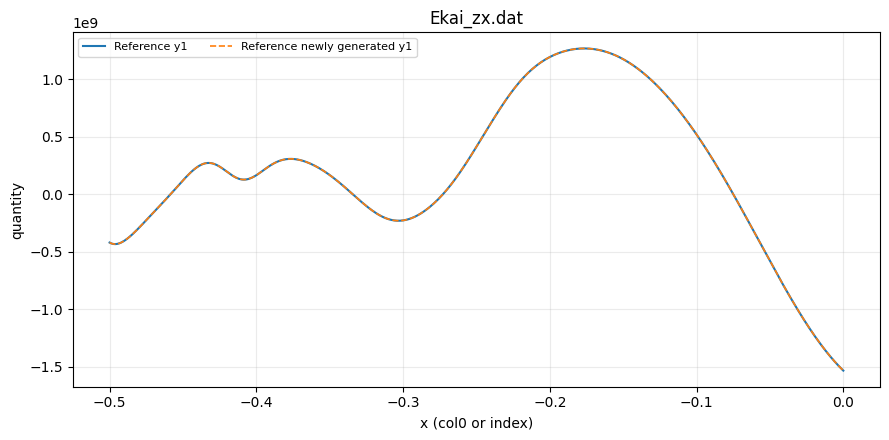

plotted: Ekai_zy.dat | table mode, plotted 1 y-column(s)


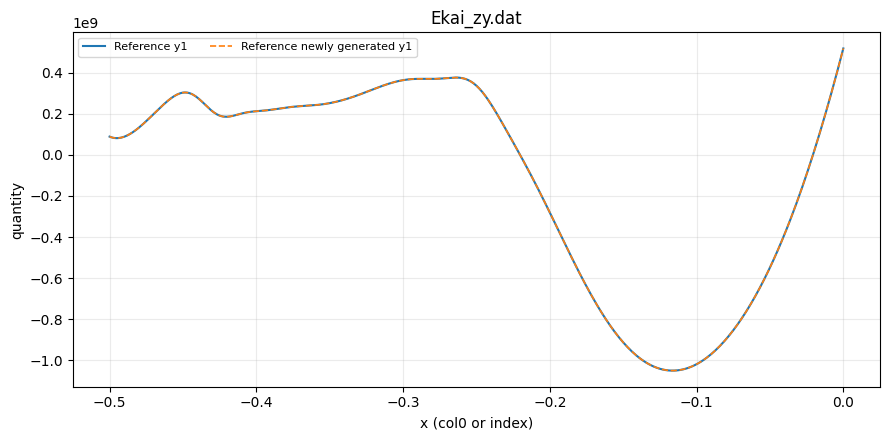

plotted: Ekai_zz.dat | table mode, plotted 1 y-column(s)


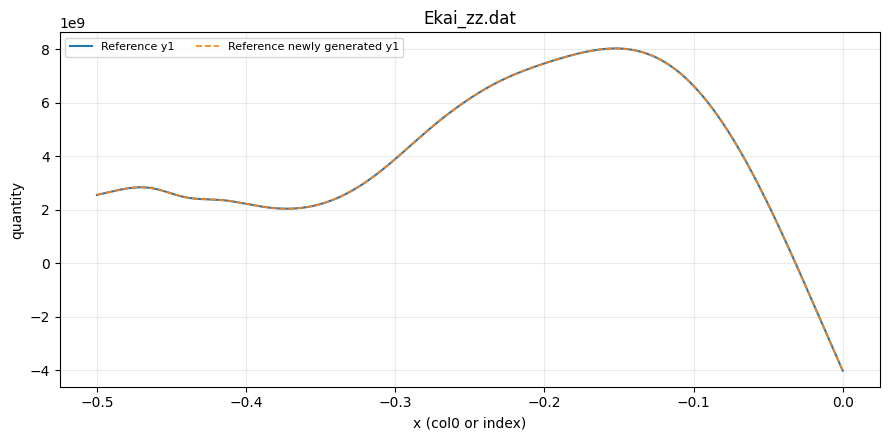

plotted: current.dat | table mode, plotted 3 y-column(s)


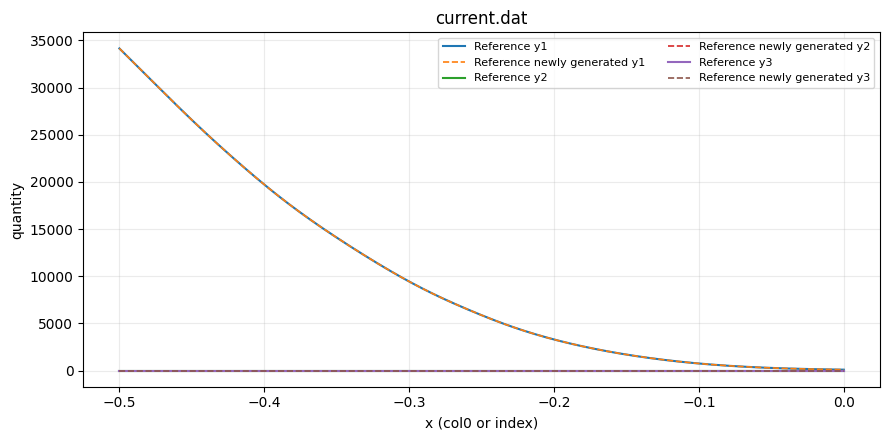

plotted: kai.dat | table mode, plotted 3 y-column(s)


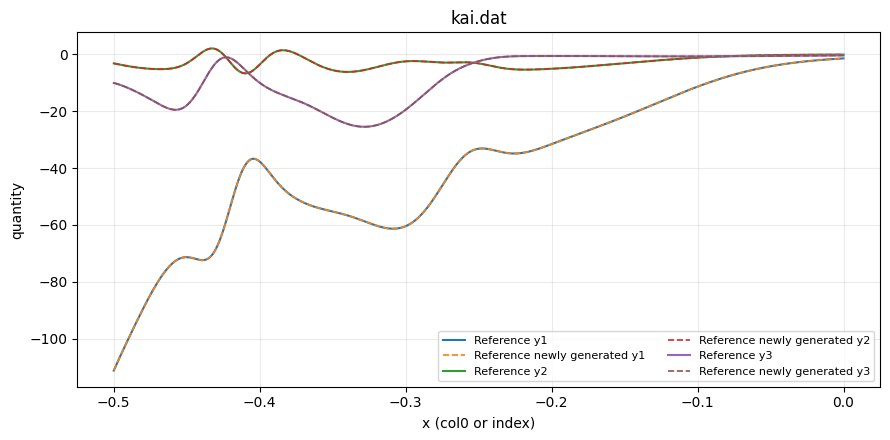

Plotted 11 file(s), skipped 2 file(s).

=== example12/ad_hoc_soc ===
Common files: 4
plotted: bands_0.dat | band mode, plotted 432 bands over 101 points


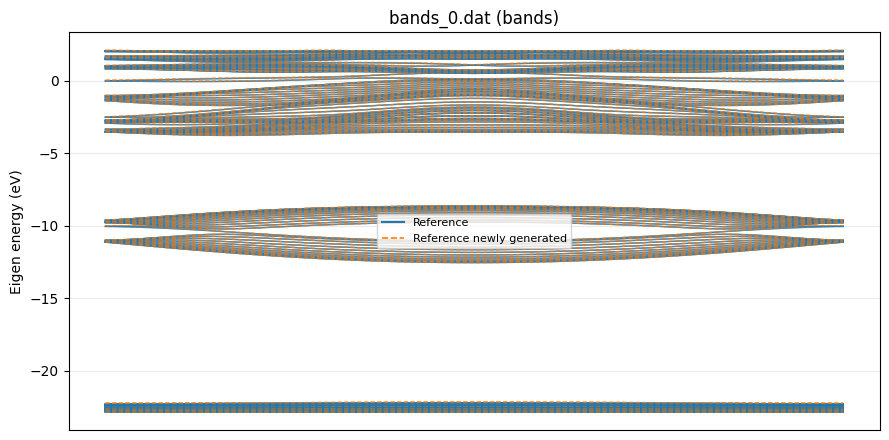

plotted: kpath_points.txt | vector mode, compared 306 values


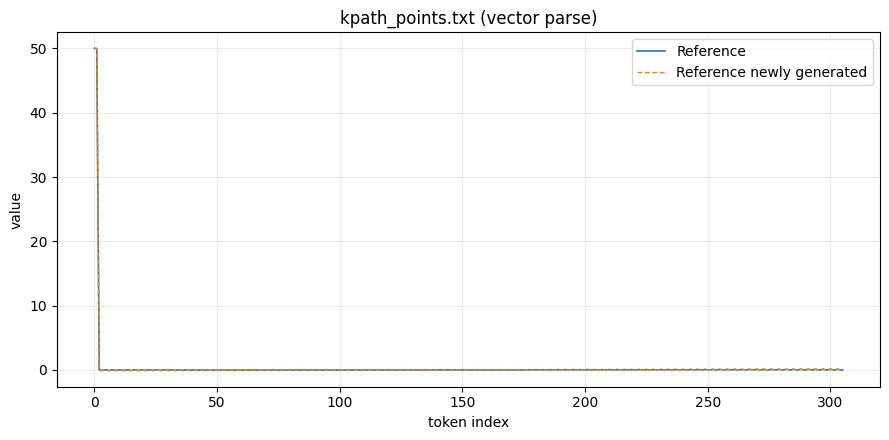

plotted: site-projected-bands_0.dat | table mode, plotted 2 y-column(s)


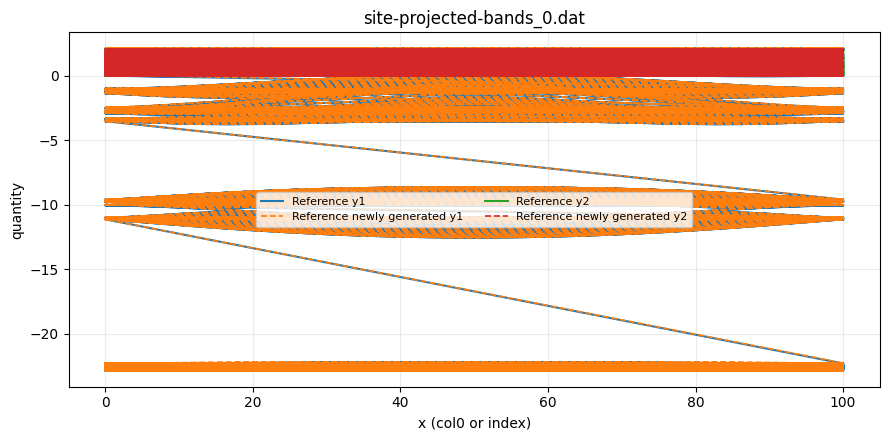

Plotted 3 file(s), skipped 1 file(s).

=== example14 ===
Common files: 6
plotted: Fermi_surf_band_1.bxsf | vector mode, compared 869 values


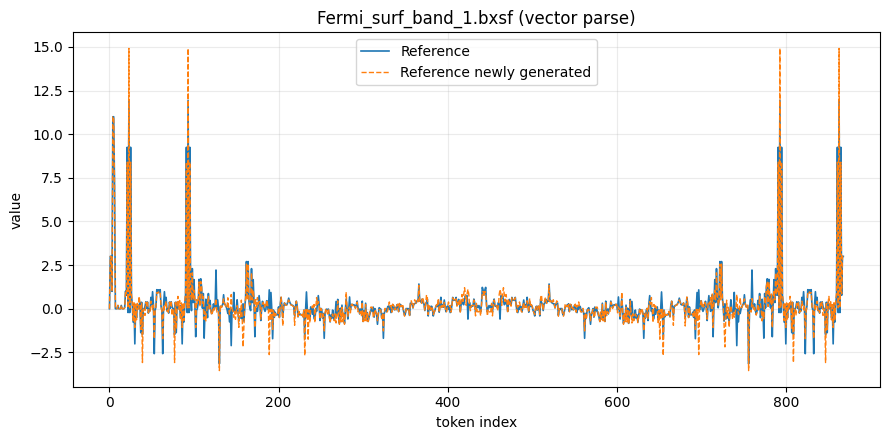

plotted: Fermi_surf_band_2.bxsf | vector mode, compared 869 values


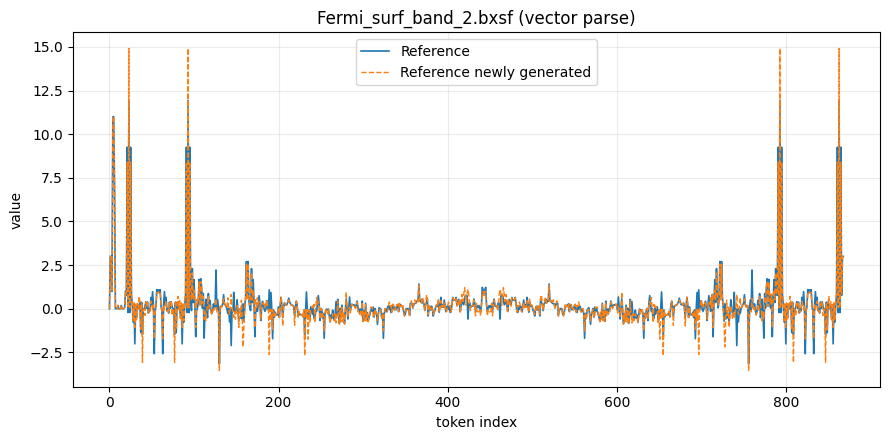

plotted: Spin_Berry_z_xy.bxsf | vector mode, compared 1719 values


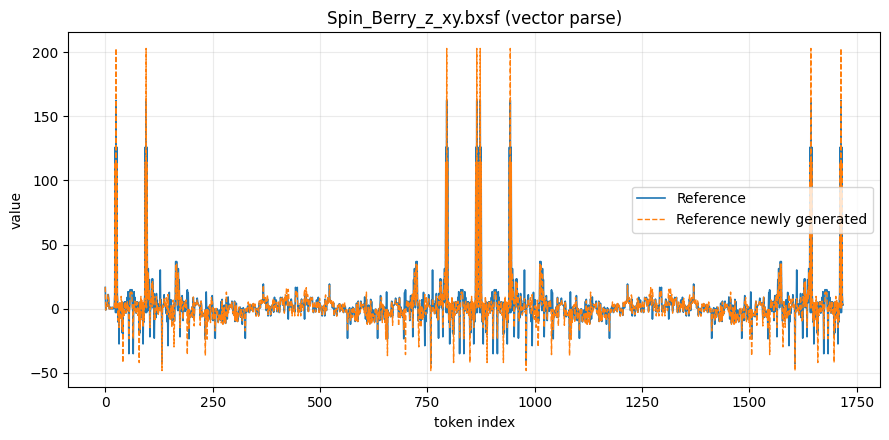

plotted: bands_0.dat | band mode, plotted 72 bands over 103 points


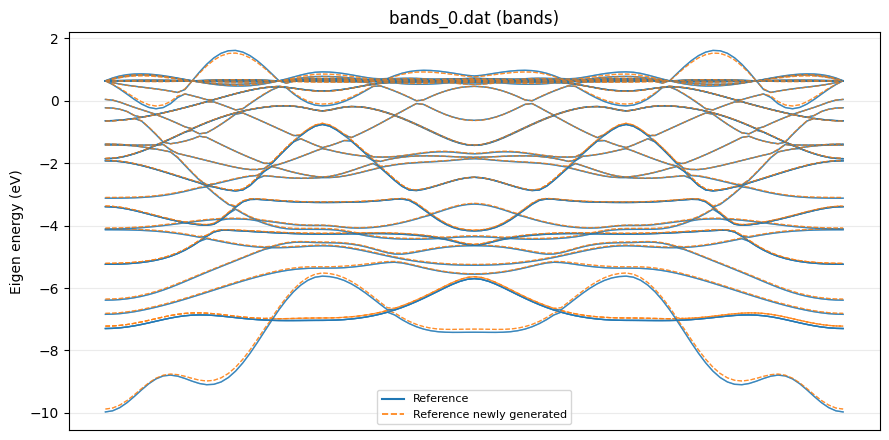

plotted: kpath_points.txt | vector mode, compared 313 values


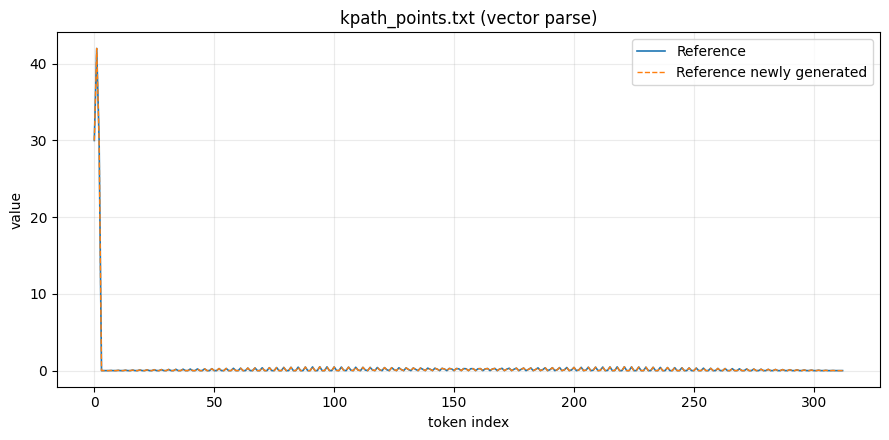

plotted: shcEf_z_xy.dat | table mode, plotted 1 y-column(s)


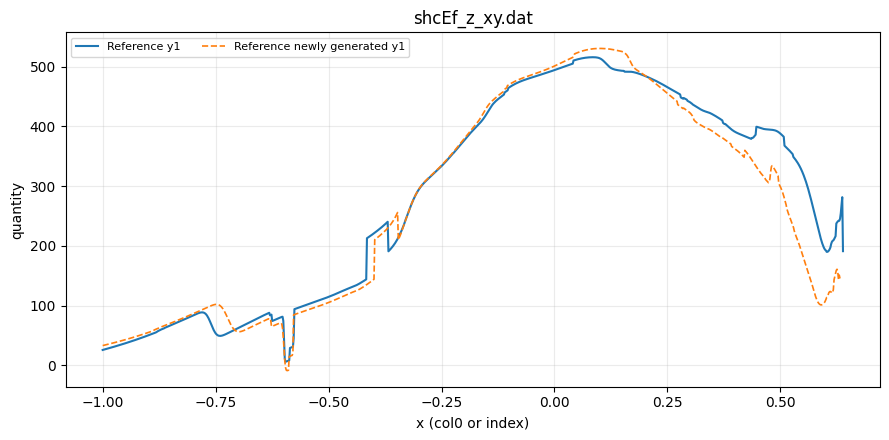

Plotted 6 file(s), skipped 0 file(s).


In [4]:
def compare_and_plot_job(job_dir: Path, qe_root: Path, baseline_name: str, candidate_name: str, max_plots: int | None = None):
    base = job_dir / baseline_name
    cand = job_dir / candidate_name

    base_files = {p.relative_to(base).as_posix(): p for p in base.rglob('*') if p.is_file()}
    cand_files = {p.relative_to(cand).as_posix(): p for p in cand.rglob('*') if p.is_file()}
    common = sorted(set(base_files.keys()) & set(cand_files.keys()))

    print('\n===', job_id(job_dir, qe_root), '===')
    print('Common files:', len(common))

    plotted = 0
    skipped = 0

    for rel in common:
        if max_plots is not None and plotted >= max_plots:
            break

        ref_file = base_files[rel]
        cand_file = cand_files[rel]

        ok, info = plot_pair(ref_file, cand_file, max_y_cols=MAX_Y_COLS)
        if ok:
            plotted += 1
            print('plotted:', rel, '|', info)
            plt.show()
            plt.close()
        else:
            skipped += 1

    print(f'Plotted {plotted} file(s), skipped {skipped} file(s).')

for jd in job_dirs:
    compare_and_plot_job(
        jd,
        QE_ROOT,
        BASELINE_DIRNAME,
        CANDIDATE_DIRNAME,
        max_plots=MAX_PLOTS_PER_JOB,
    )